# RFUAV Open-Set RF Fingerprinting — Complete Pipeline

RNN → DenseNet-121 → Swin Transformer → GNN → FreqMoE-OSR (Proposed) → Comparison → Restricted-Airspace Simulator

In [1]:
!pip install huggingface_hub -q

In [2]:
!pip install google-api-python-client google-auth -q

In [3]:
import json
from kaggle_secrets import UserSecretsClient
from google.oauth2 import service_account
from googleapiclient.discovery import build

user_secrets = UserSecretsClient()
creds_json = user_secrets.get_secret("GDRIVE_CREDS")
creds_dict = json.loads(creds_json)

credentials = service_account.Credentials.from_service_account_info(
    creds_dict, scopes=["https://www.googleapis.com/auth/drive.readonly"]
)
drive_service = build("drive", "v3", credentials=credentials)
print("Authenticated successfully!")

Authenticated successfully!


In [4]:
import urllib.request
try:
    urllib.request.urlopen("https://huggingface.co", timeout=5)
    print("Internet is WORKING ✅")
except Exception as e:
    print("Internet is OFF ❌:", e)

Internet is WORKING ✅


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show folders, limit depth to avoid huge output
        for d in dirs[:10]:
            pass
    # stop going deeper than 3 levels to avoid flooding output
    if level >= 3:
        dirs[:] = []

input/
  datasets/
    varshinirajasekaran/
      rfuav-research/
  notebooks/
    varshinirajasekaran/
      uav-research/


In [6]:
import os

correct_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research"
print("Contents:")
print(os.listdir(correct_path))

Contents:
['rfuav_images', '__huggingface_repos__.json']


In [7]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images"
print("Contents of rfuav_images:")
print(os.listdir(base_path))

Contents of rfuav_images:
['ImageSet-AllDrones-MatlabPipeline', '.cache']


In [8]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"
print("Contents:")
print(os.listdir(base_path))

Contents:
['valid', 'train']


In [9]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

train_classes = os.listdir(f"{base_path}/train")
valid_classes = os.listdir(f"{base_path}/valid")

print(f"Train classes: {len(train_classes)}")
print(train_classes)
print()
print(f"Valid classes: {len(valid_classes)}")
print(valid_classes)

Train classes: 37
['SIYI FT24', 'JUMPER-TProV2', 'DEVENTION DEVO', 'WFLY ET10', 'FLYSKY FS I6X', 'DJI AVATA2', 'DJI FPV COMBO', 'Radiolink AT10 II', 'FRSKY-X14', 'SIYI MK15', 'RadioMaster BOXER', 'FUTABA-T14SG', 'YunZhuo-H16', 'SKYDROID-T10', 'FUTABA-T16IZ', 'FRSKY-X9DP2019', 'FRSKY-X20R', 'Radiolink AT9S Pro', 'RadioMaster TX16S', 'DJI MINI4 PRO', 'YunZhuo-H12', 'WFLY ET16S', 'DJI MAVIC3 PRO', 'DJI MINI3', 'FUTABA-T18SZ', 'FLYSKY NV 14', 'FUTABA-T10J', 'SKYDROID-H12', 'WFLY WFT09SII', 'FLYSKY EL 18', 'JR PROPO XG14', 'YunZhuo-H30', 'JUMPER-T14', 'JR PROPO XG7', 'SIYI MK32', 'DAUTEL EVO nano', 'Herelink-Hx4']

Valid classes: 37
['SIYI FT24', 'JUMPER-TProV2', 'DEVENTION DEVO', 'WFLY ET10', 'FLYSKY FS I6X', 'DJI AVATA2', 'DJI FPV COMBO', 'Radiolink AT10 II', 'FRSKY-X14', 'SIYI MK15', 'RadioMaster BOXER', 'FUTABA-T14SG', 'YunZhuo-H16', 'SKYDROID-T10', 'FUTABA-T16IZ', 'FRSKY-X9DP2019', 'FRSKY-X20R', 'Radiolink AT9S Pro', 'RadioMaster TX16S', 'DJI MINI4 PRO', 'YunZhuo-H12', 'WFLY ET16S', 'D

In [10]:
all_classes = train_classes  # 37 classes, already verified

# 12 classes selected as UNKNOWN (held-out, open-set test)
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]

# Remaining 25 classes = KNOWN (used for training + validation)
known_classes = [c for c in all_classes if c not in unknown_classes]

print(f"Known classes ({len(known_classes)}):")
print(known_classes)
print()
print(f"Unknown classes ({len(unknown_classes)}):")
print(unknown_classes)

Known classes (25):
['SIYI FT24', 'JUMPER-TProV2', 'DEVENTION DEVO', 'WFLY ET10', 'FLYSKY FS I6X', 'DJI AVATA2', 'DJI FPV COMBO', 'Radiolink AT10 II', 'FRSKY-X14', 'SIYI MK15', 'RadioMaster BOXER', 'FUTABA-T14SG', 'YunZhuo-H16', 'SKYDROID-T10', 'FUTABA-T16IZ', 'FRSKY-X9DP2019', 'YunZhuo-H12', 'WFLY ET16S', 'DJI MAVIC3 PRO', 'DJI MINI3', 'FUTABA-T18SZ', 'FLYSKY NV 14', 'JR PROPO XG14', 'DAUTEL EVO nano', 'Herelink-Hx4']

Unknown classes (12):
['DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J', 'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro', 'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12']


In [11]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

def collect_filepaths(split, classes):
    """Collect all image file paths for given classes in train/valid split"""
    filepaths = []
    labels = []
    for cls in classes:
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in os.listdir(class_dir):
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

# KNOWN classes -> training data (from 'train' split)
known_train_paths, known_train_labels = collect_filepaths('train', known_classes)

# KNOWN classes -> validation data (from 'valid' split)
known_valid_paths, known_valid_labels = collect_filepaths('valid', known_classes)

# UNKNOWN classes -> test data (both train + valid combined, since model never sees these)
unknown_train_paths, unknown_train_labels = collect_filepaths('train', unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths('valid', unknown_classes)

unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known train images: {len(known_train_paths)}")
print(f"Known valid images: {len(known_valid_paths)}")
print(f"Unknown test images: {len(unknown_test_paths)}")
print(f"Total: {len(known_train_paths) + len(known_valid_paths) + len(unknown_test_paths)}")

Known train images: 4246
Known valid images: 10023
Unknown test images: 4816
Total: 19085


In [12]:
!pip install torch torchvision -q

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# Step 1: Create label encoding (class name -> integer index)
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(known_classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Class to index mapping:")
print(class_to_idx)

Class to index mapping:
{'DAUTEL EVO nano': 0, 'DEVENTION DEVO': 1, 'DJI AVATA2': 2, 'DJI FPV COMBO': 3, 'DJI MAVIC3 PRO': 4, 'DJI MINI3': 5, 'FLYSKY FS I6X': 6, 'FLYSKY NV 14': 7, 'FRSKY-X14': 8, 'FRSKY-X9DP2019': 9, 'FUTABA-T14SG': 10, 'FUTABA-T16IZ': 11, 'FUTABA-T18SZ': 12, 'Herelink-Hx4': 13, 'JR PROPO XG14': 14, 'JUMPER-TProV2': 15, 'RadioMaster BOXER': 16, 'Radiolink AT10 II': 17, 'SIYI FT24': 18, 'SIYI MK15': 19, 'SKYDROID-T10': 20, 'WFLY ET10': 21, 'WFLY ET16S': 22, 'YunZhuo-H12': 23, 'YunZhuo-H16': 24}


In [14]:
# Step 2: Custom Dataset class
class RFUAVDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label_name = self.labels[idx]
        label = self.class_to_idx[label_name]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
# Step 3: Define preprocessing transforms
# Standard spectrogram preprocessing: resize + normalize (ImageNet stats, since backbones are pretrained)

IMG_SIZE = 224  # standard for DenseNet/Swin; adjust per model later if needed

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),   # mild augmentation; spectrograms are time-frequency, flip carefully
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [16]:
# Step 4: Create Dataset instances
train_dataset = RFUAVDataset(known_train_paths, known_train_labels, class_to_idx, transform=train_transform)
valid_dataset = RFUAVDataset(known_valid_paths, known_valid_labels, class_to_idx, transform=eval_transform)

# For unknown/test set, we don't map to class_to_idx (these classes aren't in it)
# We'll handle this separately for open-set evaluation
class RFUAVUnknownDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels  # kept as string names for reference, not used in loss
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]  # return class name string, not index

unknown_test_dataset = RFUAVUnknownDataset(unknown_test_paths, unknown_test_labels, transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Unknown test dataset size: {len(unknown_test_dataset)}")

Train dataset size: 4246
Valid dataset size: 10023
Unknown test dataset size: 4816


In [17]:
# Step 5: Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_test_loader = DataLoader(unknown_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [18]:
# Step 6: Quick sanity check - fetch one batch and verify shapes
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")   # expected: [32, 3, 224, 224]
print(f"Batch labels shape: {labels.shape}")  # expected: [32]
print(f"Sample labels: {labels[:5].tolist()}")
print(f"Corresponding class names: {[idx_to_class[l.item()] for l in labels[:5]]}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Sample labels: [4, 3, 19, 15, 13]
Corresponding class names: ['DJI MAVIC3 PRO', 'DJI FPV COMBO', 'SIYI MK15', 'JUMPER-TProV2', 'Herelink-Hx4']


In [20]:
# ============================================================
# REPRODUCIBLE EXPERIMENT + RESULT SAVING
# ============================================================
import os, json, random, copy
import numpy as np
import pandas as pd
import torch

SEED = 42
RESULTS_DIR = "/kaggle/working/results"
CHECKPOINTS_DIR = "/kaggle/working/checkpoints"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def get_dataloader_generator(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return g

def save_model_result(model_name, metrics_dict):
    safe_name = model_name.replace(" ", "_").replace("-", "_")

    save_data = {}
    for k, v in metrics_dict.items():
        if k == "confusion_matrix":
            save_data[k] = v.tolist() if hasattr(v, "tolist") else v
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v

    # Individual JSON
    json_path = os.path.join(RESULTS_DIR, f"{safe_name}_metrics.json")
    with open(json_path, "w") as f:
        json.dump(save_data, f, indent=4)

    # Individual confusion matrix
    if "confusion_matrix" in metrics_dict:
        cm = np.asarray(metrics_dict["confusion_matrix"])
        pd.DataFrame(cm).to_csv(
            os.path.join(RESULTS_DIR, f"{safe_name}_confusion_matrix.csv"),
            index=False
        )

    # Individual one-row CSV
    summary = {
        k: v for k, v in save_data.items()
        if k != "confusion_matrix"
    }
    pd.DataFrame([summary]).to_csv(
        os.path.join(RESULTS_DIR, f"{safe_name}_metrics.csv"),
        index=False
    )

    # Human-readable text file
    txt_path = os.path.join(
        RESULTS_DIR,
        f"{safe_name}_metrics.txt"
    )
    with open(txt_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write("=" * 60 + "\n")
        for key, value in summary.items():
            if isinstance(value, (float, int, np.floating, np.integer)):
                f.write(f"{key}: {float(value):.6f}\n")
            else:
                f.write(f"{key}: {value}\n")

    print(f"Saved results for {model_name}")

set_seed(SEED)
print(f"Reproducibility enabled. SEED = {SEED}")


Reproducibility enabled. SEED = 42


In [21]:
# ============================================================
# RFUAV DATASET SPLIT — SAME DATA AS ORIGINAL NOTEBOOK
# ============================================================

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

train_classes = sorted(os.listdir(f"{base_path}/train"))

# 12 classes held out as UNKNOWN
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]

# Remaining 25 classes are KNOWN
known_classes = sorted([c for c in train_classes if c not in unknown_classes])

class_to_idx = {cls: idx for idx, cls in enumerate(known_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

def collect_filepaths(split, classes):
    filepaths, labels = [], []

    for cls in sorted(classes):
        class_dir = os.path.join(base_path, split, cls)

        if os.path.exists(class_dir):
            for fname in sorted(os.listdir(class_dir)):
                if fname.lower().endswith(".jpg"):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)

    return filepaths, labels

known_train_paths, known_train_labels = collect_filepaths("train", known_classes)
known_valid_paths, known_valid_labels = collect_filepaths("valid", known_classes)

unknown_train_paths, unknown_train_labels = collect_filepaths("train", unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths("valid", unknown_classes)

unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known classes   : {len(known_classes)}")
print(f"Unknown classes : {len(unknown_classes)}")
print(f"Known train     : {len(known_train_paths)}")
print(f"Known validation: {len(known_valid_paths)}")
print(f"Unknown test    : {len(unknown_test_paths)}")


Known classes   : 25
Unknown classes : 12
Known train     : 4246
Known validation: 10023
Unknown test    : 4816


In [22]:
# ============================================================
# IMPORTS + SHARED TRAINING / EVALUATION FUNCTIONS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

print(f"Using device: {device}")

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

    return total_loss / total, correct / total


def full_evaluation(model, valid_loader, unknown_loader, device, forward_fn=None):
    """
    Closed-set:
        Accuracy
        Macro Precision / Recall / F1
        Weighted Precision / Recall / F1

    Open-set:
        AUROC using maximum softmax confidence.
    """
    if forward_fn is None:
        forward_fn = lambda m, x: m(x)

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in valid_loader:
            logits = forward_fn(model, x.to(device))

            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    accuracy = accuracy_score(all_labels, all_preds)

    macro_precision = precision_score(
        all_labels, all_preds, average="macro", zero_division=0
    )
    macro_recall = recall_score(
        all_labels, all_preds, average="macro", zero_division=0
    )
    macro_f1 = f1_score(
        all_labels, all_preds, average="macro", zero_division=0
    )

    weighted_precision = precision_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    weighted_recall = recall_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    weighted_f1 = f1_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    # Known confidence
    known_probs = []
    with torch.no_grad():
        for x, _ in valid_loader:
            logits = forward_fn(model, x.to(device))
            known_probs.extend(
                F.softmax(logits, dim=1).max(1)[0].cpu().numpy()
            )

    # Unknown confidence
    unknown_probs = []
    with torch.no_grad():
        for x, _ in unknown_loader:
            logits = forward_fn(model, x.to(device))
            unknown_probs.extend(
                F.softmax(logits, dim=1).max(1)[0].cpu().numpy()
            )

    y_true_binary = np.concatenate([
        np.ones(len(known_probs)),
        np.zeros(len(unknown_probs))
    ])

    confidence_scores = np.concatenate([
        known_probs,
        unknown_probs
    ])

    auroc = roc_auc_score(
        y_true_binary,
        confidence_scores
    )

    print("\n" + "=" * 70)
    print("MODEL METRICS")
    print("=" * 70)
    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Macro Precision    : {macro_precision:.4f}")
    print(f"Macro Recall       : {macro_recall:.4f}")
    print(f"Macro F1-score     : {macro_f1:.4f}")
    print(f"Weighted Precision : {weighted_precision:.4f}")
    print(f"Weighted Recall    : {weighted_recall:.4f}")
    print(f"Weighted F1-score  : {weighted_f1:.4f}")
    print(f"Open-set AUROC     : {auroc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "auroc": auroc,
        "confusion_matrix": cm
    }


def plot_confusion(cm, title):
    class_names = [
        idx_to_class[i]
        for i in range(len(known_classes))
    ]

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


print("Shared utilities ready!")


Using device: cuda
Shared utilities ready!


In [23]:
# ============================================================
# DETERMINISTIC DATALOADER HELPERS
# ============================================================

def make_train_loader(dataset, batch_size=32, num_workers=2, seed=SEED):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=get_dataloader_generator(seed)
    )

def make_eval_loader(dataset, batch_size=32, num_workers=2):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

print("Deterministic DataLoader helpers ready!")


Deterministic DataLoader helpers ready!


In [24]:
def collect_filepaths(split, classes):
    filepaths, labels = [], []
    for cls in sorted(classes):  # sort class order
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in sorted(os.listdir(class_dir)):  # sort file order
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

# 1. RNN (Bidirectional LSTM) Baseline


In [24]:
import os
import json
import numpy as np

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist()
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save system ready!")

Save system ready!


In [25]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"
train_classes = os.listdir(f"{base_path}/train")

all_classes = train_classes
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]
known_classes = [c for c in all_classes if c not in unknown_classes]

class_to_idx = {cls: idx for idx, cls in enumerate(sorted(known_classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

def collect_filepaths(split, classes):
    filepaths, labels = [], []
    for cls in classes:
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in os.listdir(class_dir):
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

known_train_paths, known_train_labels = collect_filepaths('train', known_classes)
known_valid_paths, known_valid_labels = collect_filepaths('valid', known_classes)
unknown_train_paths, unknown_train_labels = collect_filepaths('train', unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths('valid', unknown_classes)
unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known: {len(known_classes)}, Unknown: {len(unknown_classes)}")
print(f"Train: {len(known_train_paths)}, Valid: {len(known_valid_paths)}, Unknown test: {len(unknown_test_paths)}")

Known: 25, Unknown: 12
Train: 4246, Valid: 10023, Unknown test: 4816


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [27]:
IMG_SIZE = 224

class RFUAVSequenceDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, img_size=224):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.img_size = img_size

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('L')
        image = image.resize((self.img_size, self.img_size))
        image = np.array(image, dtype=np.float32) / 255.0
        sequence = torch.tensor(image.T, dtype=torch.float32)
        return sequence, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownSequenceDataset(Dataset):
    def __init__(self, filepaths, labels, img_size=224):
        self.filepaths = filepaths
        self.labels = labels
        self.img_size = img_size

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('L')
        image = image.resize((self.img_size, self.img_size))
        image = np.array(image, dtype=np.float32) / 255.0
        sequence = torch.tensor(image.T, dtype=torch.float32)
        return sequence, self.labels[idx]

train_seq_dataset = RFUAVSequenceDataset(known_train_paths, known_train_labels, class_to_idx, IMG_SIZE)
valid_seq_dataset = RFUAVSequenceDataset(known_valid_paths, known_valid_labels, class_to_idx, IMG_SIZE)
unknown_seq_dataset = RFUAVUnknownSequenceDataset(unknown_test_paths, unknown_test_labels, IMG_SIZE)

BATCH_SIZE = 32
train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_seq_loader = DataLoader(valid_seq_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
unknown_seq_loader = DataLoader(unknown_seq_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready!")

DataLoaders ready!


In [28]:
class RNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, num_classes=25, bidirectional=True):
        super(RNNClassifier, self).__init__()
        self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional, dropout=0.3 if num_layers > 1 else 0)
        direction_factor = 2 if bidirectional else 1
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * direction_factor, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        last_hidden = rnn_out[:, -1, :]
        return self.classifier(last_hidden)

model = RNNClassifier(input_dim=IMG_SIZE, hidden_dim=128, num_layers=2,
                       num_classes=len(known_classes), bidirectional=True).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 793,881


In [29]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * sequences.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += sequences.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * sequences.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += sequences.size(0)
    return total_loss / total, correct / total

NUM_EPOCHS = 20
best_valid_acc = 0
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_seq_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_seq_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Epoch 1/20 | Train Loss: 2.9973, Train Acc: 0.1234 | Valid Loss: 2.7902, Valid Acc: 0.1851
Epoch 2/20 | Train Loss: 2.6298, Train Acc: 0.1875 | Valid Loss: 2.3547, Valid Acc: 0.2377
Epoch 3/20 | Train Loss: 2.6413, Train Acc: 0.1710 | Valid Loss: 2.6079, Valid Acc: 0.1490
Epoch 4/20 | Train Loss: 2.5408, Train Acc: 0.1816 | Valid Loss: 2.4333, Valid Acc: 0.1819
Epoch 5/20 | Train Loss: 2.4696, Train Acc: 0.2009 | Valid Loss: 2.3715, Valid Acc: 0.2097
Epoch 6/20 | Train Loss: 2.3673, Train Acc: 0.2061 | Valid Loss: 2.3027, Valid Acc: 0.2206
Epoch 7/20 | Train Loss: 2.2928, Train Acc: 0.2409 | Valid Loss: 2.3085, Valid Acc: 0.2004
Epoch 8/20 | Train Loss: 2.2561, Train Acc: 0.2555 | Valid Loss: 2.1717, Valid Acc: 0.2594
Epoch 9/20 | Train Loss: 2.2006, Train Acc: 0.2626 | Valid Loss: 2.1387, Valid Acc: 0.2898
Epoch 10/20 | Train Loss: 2.2218, Train Acc: 0.2522 | Valid Loss: 2.0839, Valid Acc: 0.3098
Epoch 11/20 | Train Loss: 2.1492, Train Acc: 0.2704 | Valid Loss: 2.0216, Valid Acc: 0.31

Accuracy: 0.4666
Macro Precision: 0.2684, Macro Recall: 0.3140, Macro F1: 0.2613
Weighted Precision: 0.3809, Weighted Recall: 0.4666, Weighted F1: 0.3969
Open-Set AUROC: 0.6758


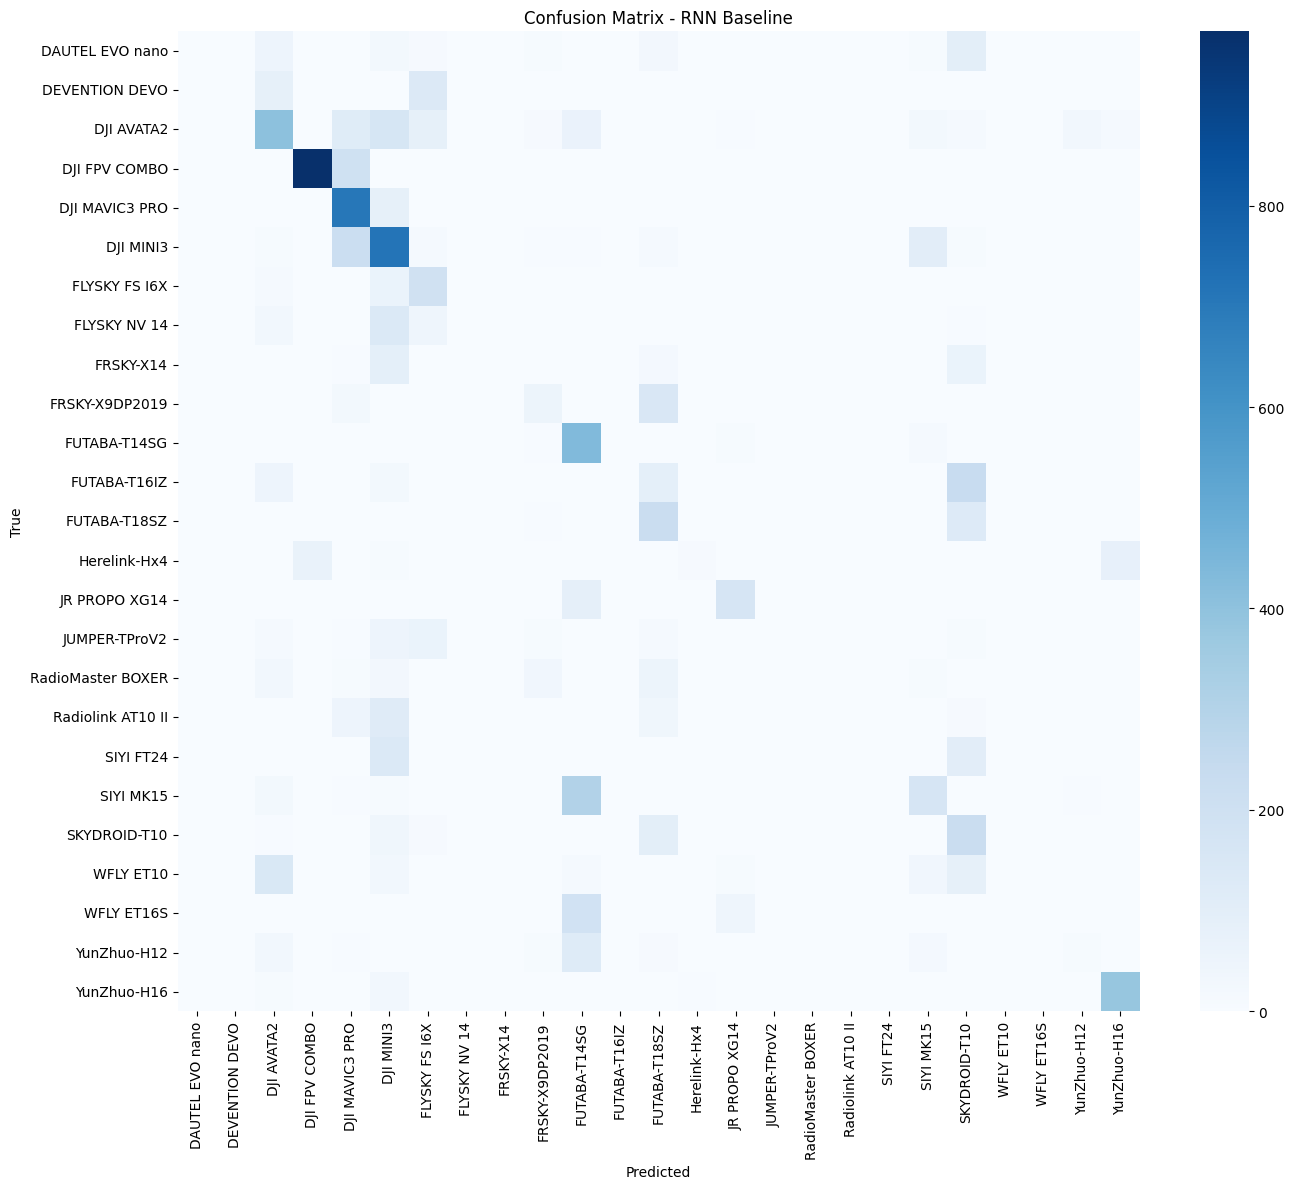

Saved permanently: /kaggle/working/results/RNN.json


In [30]:
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for sequences, labels in valid_seq_loader:
        sequences = sequences.to(device)
        outputs = model(sequences)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for sequences, labels in valid_seq_loader:
        sequences = sequences.to(device)
        outputs = F.softmax(model(sequences), dim=1)
        known_probs.extend(outputs.max(dim=1)[0].cpu().numpy())
    for sequences, labels in unknown_seq_loader:
        sequences = sequences.to(device)
        outputs = F.softmax(model(sequences), dim=1)
        unknown_probs.extend(outputs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}, Weighted Recall: {weighted_recall:.4f}, Weighted F1: {weighted_f1:.4f}")
print(f"Open-Set AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RNN Baseline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rnn_results = {
    'accuracy': accuracy,
    'macro_precision': macro_precision,
    'macro_recall': macro_recall,
    'macro_f1': macro_f1,
    'weighted_precision': weighted_precision,
    'weighted_recall': weighted_recall,
    'weighted_f1': weighted_f1,
    'auroc': auroc,
    'confusion_matrix': cm
}

# PERMANENT SAVE - connected to save system
save_model_result('RNN', rnn_results)

In [31]:
import os
print(os.listdir("/kaggle/working/results"))

['RNN.json']


In [32]:
print("accuracy" in dir())

True


In [33]:
def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist() if hasattr(v, 'tolist') else v
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save function updated!")

Save function updated!


In [50]:
save_model_result('RNN', {
    'accuracy': 0.4996,
    'macro_precision': 0.2809,
    'macro_recall': 0.3360,
    'macro_f1': 0.2773,
    'weighted_precision': 0.4315,
    'weighted_recall': 0.4996,
    'weighted_f1': 0.4352,
    'auroc': 0.6721,
    'confusion_matrix': [[0]]
})

Saved results for RNN


# 2. DenseNet-121 (Transfer Learning)

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [45]:
print("known_train_paths" in dir())

True


In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths, self.labels, self.class_to_idx, self.transform = filepaths, labels, class_to_idx, transform
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, torch.tensor(self.class_to_idx[self.labels[idx]], dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths, self.labels, self.transform = filepaths, labels, transform
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DenseNet DataLoaders ready!")

DenseNet DataLoaders ready!


In [49]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Image DataLoaders ready!")

Image DataLoaders ready!


In [53]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = DenseNetClassifier(num_classes=len(known_classes), pretrained=True).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 7,222,681


In [54]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super().__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x): return self.backbone(x)

model = DenseNetClassifier(num_classes=len(known_classes), pretrained=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*images.size(0); correct += (outputs.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()*images.size(0); correct += (outputs.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Epoch 1/15 | Train Loss: 1.2437, Train Acc: 0.7494 | Valid Loss: 0.2083, Valid Acc: 0.9548
Epoch 2/15 | Train Loss: 0.1666, Train Acc: 0.9673 | Valid Loss: 0.0597, Valid Acc: 0.9846
Epoch 3/15 | Train Loss: 0.0755, Train Acc: 0.9833 | Valid Loss: 0.0336, Valid Acc: 0.9913
Epoch 4/15 | Train Loss: 0.0625, Train Acc: 0.9837 | Valid Loss: 0.0207, Valid Acc: 0.9946
Epoch 5/15 | Train Loss: 0.0247, Train Acc: 0.9962 | Valid Loss: 0.0166, Valid Acc: 0.9964
Epoch 6/15 | Train Loss: 0.0278, Train Acc: 0.9948 | Valid Loss: 0.0608, Valid Acc: 0.9793
Epoch 7/15 | Train Loss: 0.0222, Train Acc: 0.9948 | Valid Loss: 0.0474, Valid Acc: 0.9862
Epoch 8/15 | Train Loss: 0.0185, Train Acc: 0.9967 | Valid Loss: 0.0136, Valid Acc: 0.9968
Epoch 9/15 | Train Loss: 0.0113, Train Acc: 0.9984 | Valid Loss: 0.0120, Valid Acc: 0.9966
Epoch 10/15 | Train Loss: 0.0144, Train Acc: 0.9962 | Valid Loss: 0.0143, Valid Acc: 0.9963
Epoch 11/15 | Train Loss: 0.0086, Train Acc: 0.9981 | Valid Loss: 0.0450, Valid Acc: 0.98

Accuracy: 0.9966, Macro F1: 0.9954, Weighted F1: 0.9966, AUROC: 0.9520


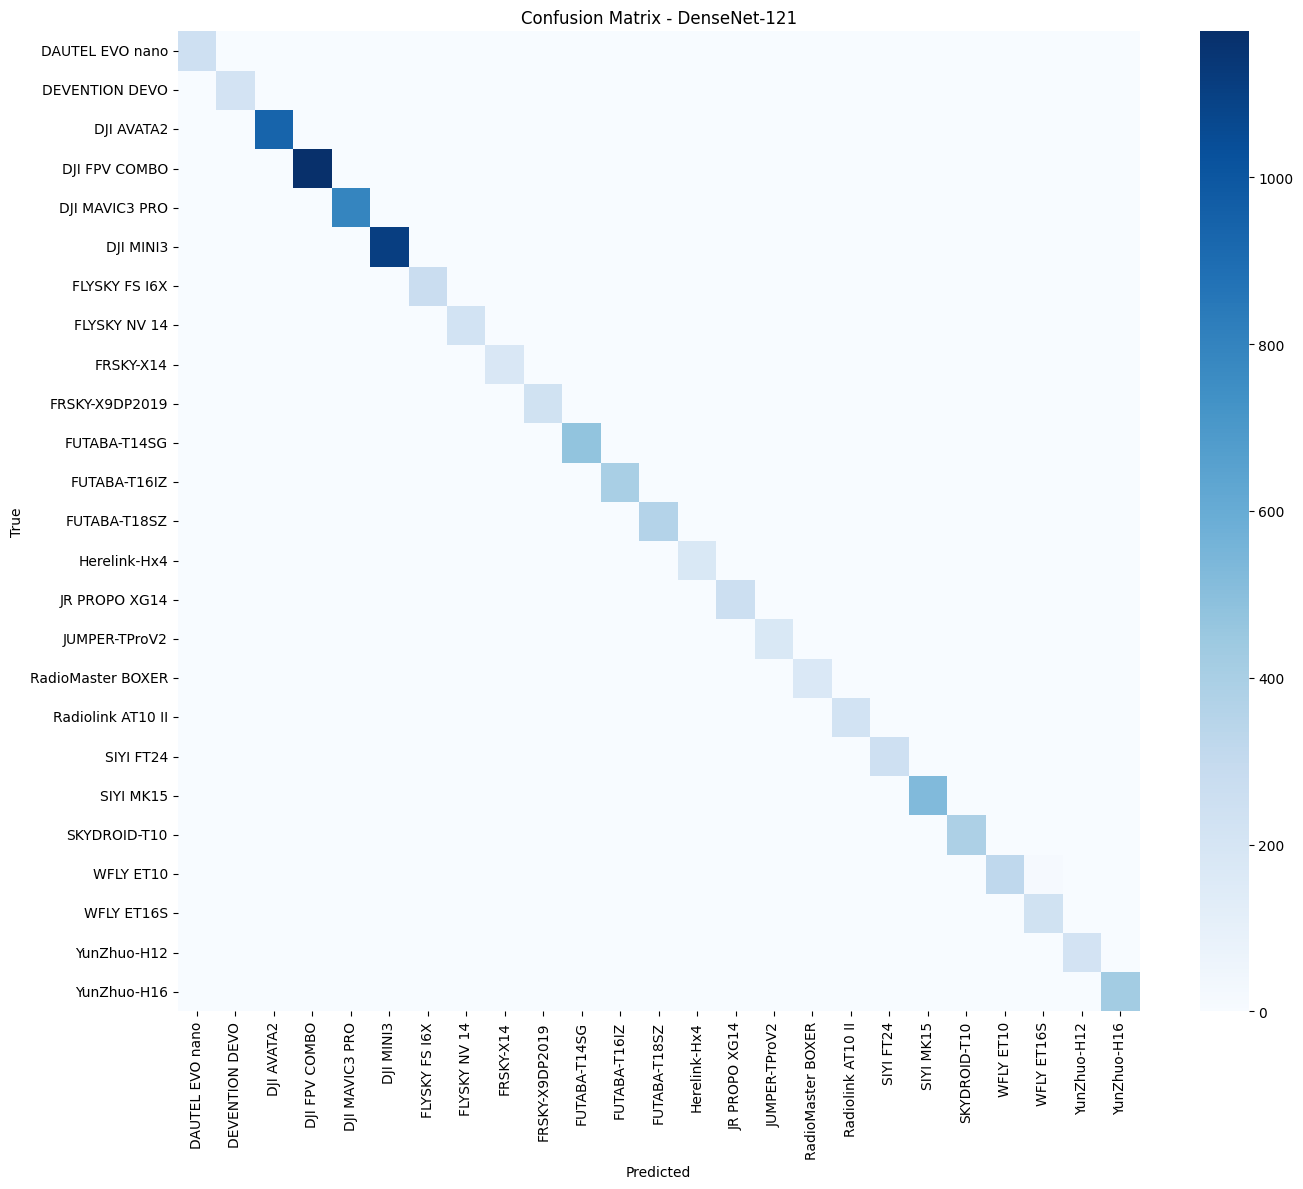

Saved permanently: /kaggle/working/results/DenseNet-121.json


In [55]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        known_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        unknown_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - DenseNet-121'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('DenseNet-121', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

In [56]:
import os, json
import numpy as np

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist()
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save system ready!")

Save system ready!


In [51]:
save_model_result('DenseNet-121', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

Saved results for DenseNet-121


# 3. Swin Transformer (Transfer Learning) — reuses DenseNet's image DataLoaders

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Image DataLoaders ready!")

Image DataLoaders ready!


In [27]:
class SwinClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super().__init__()
        self.backbone = models.swin_t(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.head.in_features
        self.backbone.head = nn.Sequential(nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x): return self.backbone(x)

model = SwinClassifier(num_classes=len(known_classes), pretrained=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:01<00:00, 96.6MB/s] 


Epoch 1/15 | Train Loss: 0.9599, Train Acc: 0.7421 | Valid Loss: 0.1208, Valid Acc: 0.9488
Epoch 2/15 | Train Loss: 0.1335, Train Acc: 0.9661 | Valid Loss: 0.0291, Valid Acc: 0.9927
Epoch 3/15 | Train Loss: 0.1001, Train Acc: 0.9734 | Valid Loss: 0.0382, Valid Acc: 0.9869
Epoch 4/15 | Train Loss: 0.0513, Train Acc: 0.9866 | Valid Loss: 0.0312, Valid Acc: 0.9933
Epoch 5/15 | Train Loss: 0.0538, Train Acc: 0.9875 | Valid Loss: 0.0295, Valid Acc: 0.9903
Epoch 6/15 | Train Loss: 0.0191, Train Acc: 0.9965 | Valid Loss: 0.0241, Valid Acc: 0.9936
Epoch 7/15 | Train Loss: 0.0237, Train Acc: 0.9941 | Valid Loss: 0.0223, Valid Acc: 0.9938
Epoch 8/15 | Train Loss: 0.0173, Train Acc: 0.9960 | Valid Loss: 0.0171, Valid Acc: 0.9964
Epoch 9/15 | Train Loss: 0.0202, Train Acc: 0.9955 | Valid Loss: 0.0222, Valid Acc: 0.9949
Epoch 10/15 | Train Loss: 0.0109, Train Acc: 0.9976 | Valid Loss: 0.0170, Valid Acc: 0.9960
Epoch 11/15 | Train Loss: 0.0176, Train Acc: 0.9958 | Valid Loss: 0.0164, Valid Acc: 0.99

Accuracy: 0.9951, Macro F1: 0.9938, Weighted F1: 0.9951, AUROC: 0.9131


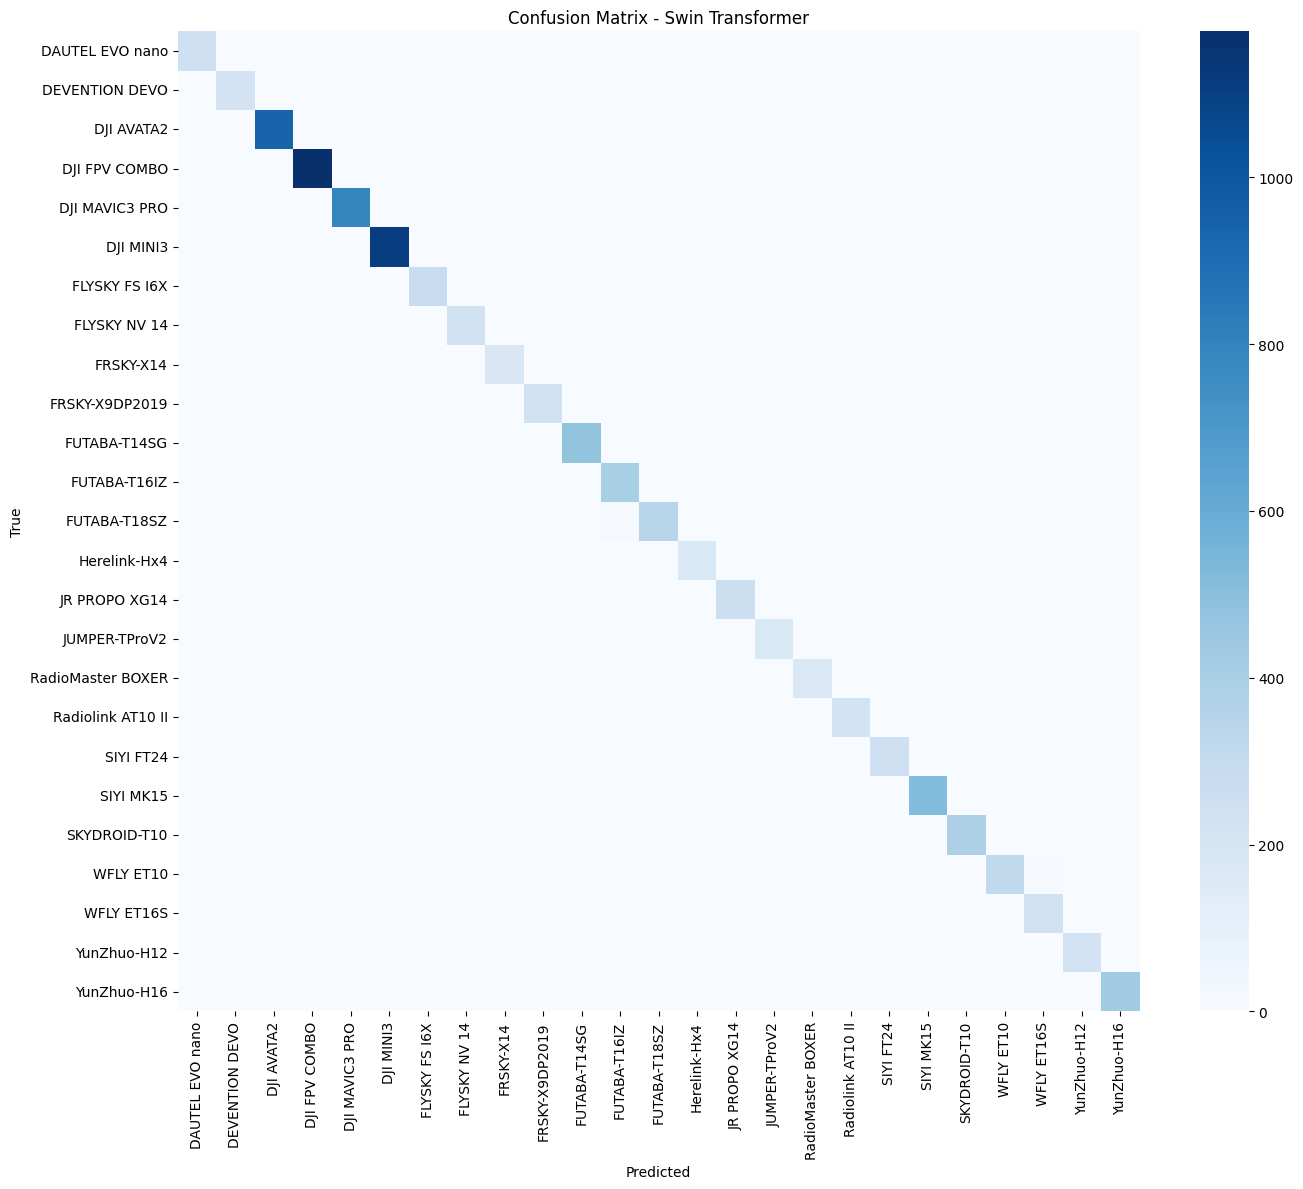

Saved results for Swin_Transformer


In [28]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        known_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        unknown_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Swin Transformer'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('Swin_Transformer', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 4. GNN (Simple GCN) Baseline

In [29]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00a 0:00:01


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [31]:
def image_to_graph(image_tensor, patch_size=16):
    C, H, W = image_tensor.shape
    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    num_nodes = n_patches_h * n_patches_w

    patches = image_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.contiguous().view(C, num_nodes, patch_size * patch_size)
    node_features = patches.permute(1, 0, 2).reshape(num_nodes, -1)

    edge_index = []
    for i in range(n_patches_h):
        for j in range(n_patches_w):
            idx = i * n_patches_w + j
            if j < n_patches_w - 1:
                edge_index.append([idx, idx + 1])
                edge_index.append([idx + 1, idx])
            if i < n_patches_h - 1:
                edge_index.append([idx, idx + n_patches_w])
                edge_index.append([idx + n_patches_w, idx])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=node_features, edge_index=edge_index)

In [32]:
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool

PATCH_SIZE = 16

def image_to_graph(image_tensor, patch_size=16):
    C, H, W = image_tensor.shape
    n_h, n_w = H // patch_size, W // patch_size
    num_nodes = n_h * n_w
    patches = image_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.contiguous().view(C, num_nodes, patch_size*patch_size)
    node_features = patches.permute(1,0,2).reshape(num_nodes, -1)
    edge_index = []
    for i in range(n_h):
        for j in range(n_w):
            idx = i*n_w+j
            if j < n_w-1: edge_index += [[idx, idx+1],[idx+1, idx]]
            if i < n_h-1: edge_index += [[idx, idx+n_w],[idx+n_w, idx]]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=node_features, edge_index=edge_index)

class RFUAVGraphDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None, patch_size=16):
        self.filepaths, self.labels, self.class_to_idx, self.transform, self.patch_size = filepaths, labels, class_to_idx, transform, patch_size
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        g = image_to_graph(image, self.patch_size)
        g.y = torch.tensor([self.class_to_idx[self.labels[idx]]], dtype=torch.long)
        return g

class RFUAVUnknownGraphDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None, patch_size=16):
        self.filepaths, self.labels, self.transform, self.patch_size = filepaths, labels, transform, patch_size
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image_to_graph(image, self.patch_size)

def graph_collate_fn(batch): return Batch.from_data_list(batch)

graph_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

train_graph_dataset = RFUAVGraphDataset(known_train_paths, known_train_labels, class_to_idx, graph_transform, PATCH_SIZE)
valid_graph_dataset = RFUAVGraphDataset(known_valid_paths, known_valid_labels, class_to_idx, graph_transform, PATCH_SIZE)
unknown_graph_dataset = RFUAVUnknownGraphDataset(unknown_test_paths, unknown_test_labels, graph_transform, PATCH_SIZE)

train_graph_loader = DataLoader(train_graph_dataset, batch_size=16, shuffle=True, collate_fn=graph_collate_fn, num_workers=2)
valid_graph_loader = DataLoader(valid_graph_dataset, batch_size=16, shuffle=False, collate_fn=graph_collate_fn, num_workers=2)
unknown_graph_loader = DataLoader(unknown_graph_dataset, batch_size=16, shuffle=False, collate_fn=graph_collate_fn, num_workers=2)
print("Graph DataLoaders ready!")

Graph DataLoaders ready!


In [33]:
train_graph_dataset = RFUAVGraphDataset(known_train_paths, known_train_labels, class_to_idx,
                                          transform=eval_transform, patch_size=PATCH_SIZE)
valid_graph_dataset = RFUAVGraphDataset(known_valid_paths, known_valid_labels, class_to_idx,
                                          transform=eval_transform, patch_size=PATCH_SIZE)
unknown_graph_dataset = RFUAVUnknownGraphDataset(unknown_test_paths, unknown_test_labels,
                                                   transform=eval_transform, patch_size=PATCH_SIZE)

BATCH_SIZE = 16  # smaller batch size since graphs are memory-heavier

train_graph_loader = DataLoader(train_graph_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  collate_fn=graph_collate_fn, num_workers=2)
valid_graph_loader = DataLoader(valid_graph_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                  collate_fn=graph_collate_fn, num_workers=2)
unknown_graph_loader = DataLoader(unknown_graph_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                    collate_fn=graph_collate_fn, num_workers=2)

# Sanity check
sample_batch = next(iter(train_graph_loader))
print(f"Batch node features shape: {sample_batch.x.shape}")
print(f"Batch edge_index shape: {sample_batch.edge_index.shape}")
print(f"Batch labels: {sample_batch.y}")

Batch node features shape: torch.Size([3136, 768])
Batch edge_index shape: torch.Size([2, 11648])
Batch labels: tensor([15, 15,  4,  9,  2, 21,  3, 20, 11,  5, 14, 19,  2, 12, 10,  0])


In [34]:
class SimpleGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=25):
        super().__init__()
        self.node_embed = nn.Linear(input_dim, hidden_dim)
        self.gcn1, self.gcn2, self.gcn3 = GCNConv(hidden_dim,hidden_dim), GCNConv(hidden_dim,hidden_dim), GCNConv(hidden_dim,hidden_dim)
        self.bn1, self.bn2, self.bn3 = nn.BatchNorm1d(hidden_dim), nn.BatchNorm1d(hidden_dim), nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,num_classes))
    def forward(self, x, edge_index, batch):
        x = F.relu(self.node_embed(x))
        x = F.relu(self.bn1(self.gcn1(x, edge_index)))
        x = F.relu(self.bn2(self.gcn2(x, edge_index)))
        x = F.relu(self.bn3(self.gcn3(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

input_dim = 3*PATCH_SIZE*PATCH_SIZE
model = SimpleGCN(input_dim=input_dim, hidden_dim=128, num_classes=len(known_classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device); optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*batch.num_graphs; correct += (out.argmax(1)==batch.y).sum().item(); total += batch.num_graphs
    return total_loss/total, correct/total

def evaluate_gnn(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item()*batch.num_graphs; correct += (out.argmax(1)==batch.y).sum().item(); total += batch.num_graphs
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch_gnn(model, train_graph_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_gnn(model, valid_graph_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Epoch 1/15 | Train Loss: 2.2825, Train Acc: 0.3097 | Valid Loss: 1.8814, Valid Acc: 0.3825
Epoch 2/15 | Train Loss: 1.7192, Train Acc: 0.4355 | Valid Loss: 1.9725, Valid Acc: 0.4058
Epoch 3/15 | Train Loss: 1.4593, Train Acc: 0.5052 | Valid Loss: 1.4594, Valid Acc: 0.5289
Epoch 4/15 | Train Loss: 1.3284, Train Acc: 0.5323 | Valid Loss: 2.3281, Valid Acc: 0.4249
Epoch 5/15 | Train Loss: 1.2045, Train Acc: 0.5827 | Valid Loss: 1.2553, Valid Acc: 0.5740
Epoch 6/15 | Train Loss: 1.1209, Train Acc: 0.6065 | Valid Loss: 1.9973, Valid Acc: 0.4769
Epoch 7/15 | Train Loss: 1.0322, Train Acc: 0.6448 | Valid Loss: 1.0956, Valid Acc: 0.5837
Epoch 8/15 | Train Loss: 0.9658, Train Acc: 0.6637 | Valid Loss: 1.0681, Valid Acc: 0.6007
Epoch 9/15 | Train Loss: 0.8843, Train Acc: 0.7011 | Valid Loss: 1.7277, Valid Acc: 0.5075
Epoch 10/15 | Train Loss: 0.8046, Train Acc: 0.7242 | Valid Loss: 0.6779, Valid Acc: 0.7821
Epoch 11/15 | Train Loss: 0.7770, Train Acc: 0.7339 | Valid Loss: 1.6493, Valid Acc: 0.52

Accuracy: 0.7050, Macro F1: 0.6057, Weighted F1: 0.6754, AUROC: 0.7326


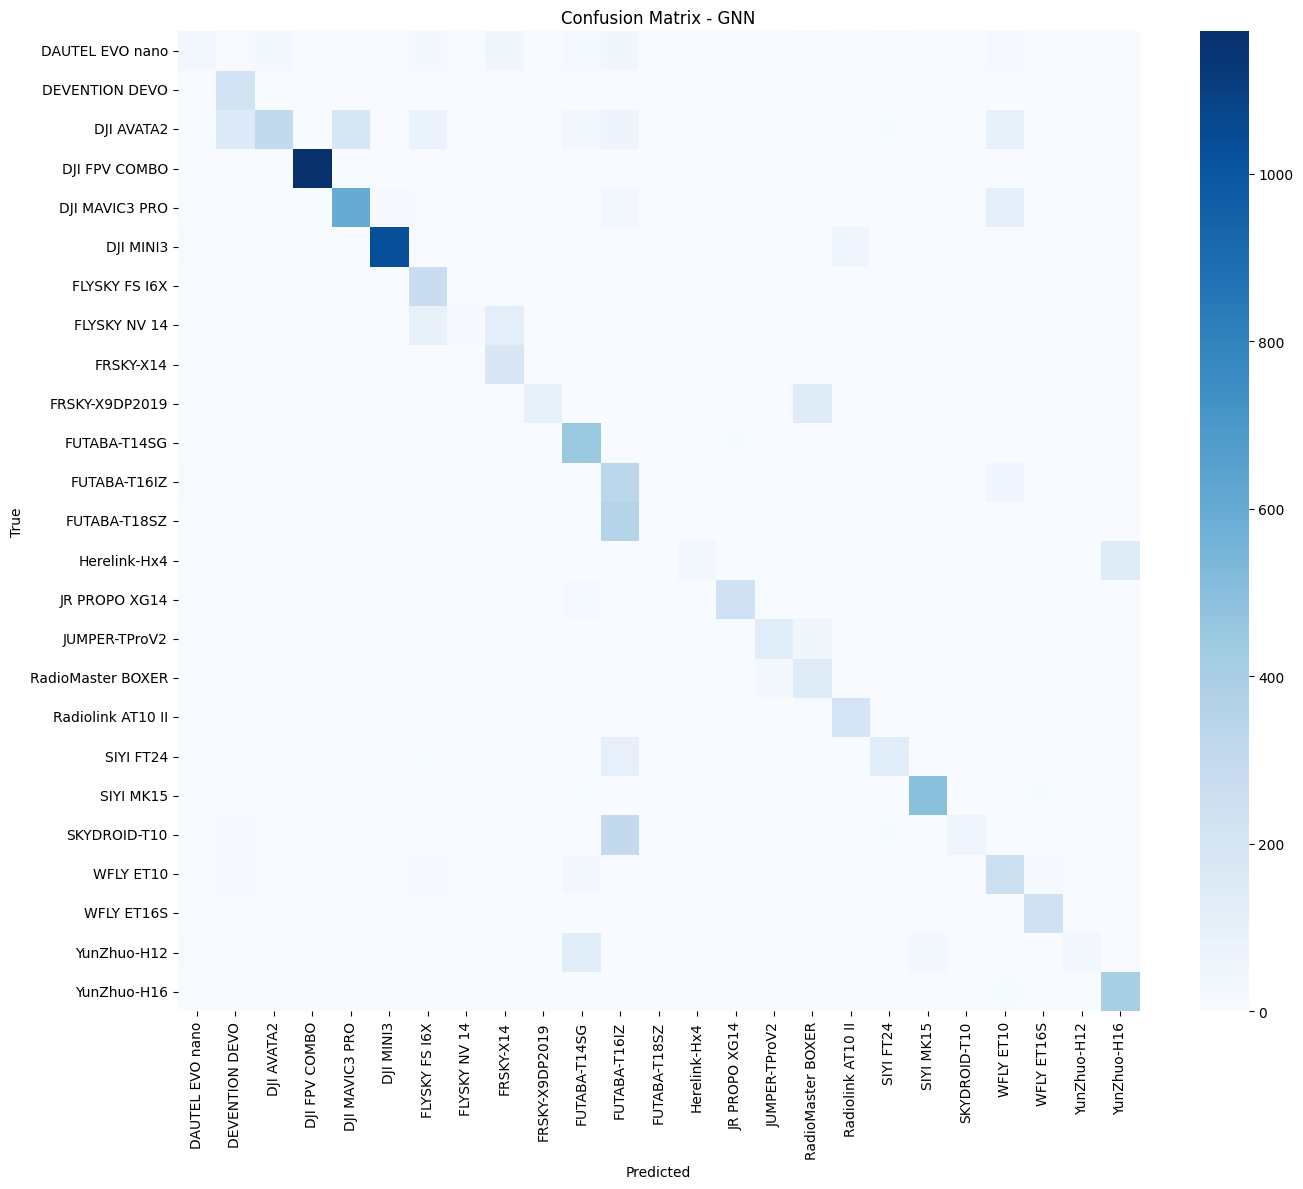

Saved results for GNN


In [35]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in valid_graph_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(1).cpu().numpy()); all_labels.extend(batch.y.cpu().numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for batch in valid_graph_loader:
        batch = batch.to(device)
        out = F.softmax(model(batch.x, batch.edge_index, batch.batch),1)
        known_probs.extend(out.max(1)[0].cpu().numpy())
    for batch in unknown_graph_loader:
        batch = batch.to(device)
        out = F.softmax(model(batch.x, batch.edge_index, batch.batch),1)
        unknown_probs.extend(out.max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - GNN'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('GNN', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 5. FreqMoE-OSR (Proposed) — Frequency-Band Mixture-of-Experts

Each frequency-band expert uses a pretrained ResNet-18; open-set detection uses softmax confidence (validated more reliable than routing entropy for this dataset).

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [38]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready!")

DataLoaders ready!


In [39]:
class FrequencyExpert(nn.Module):
    def __init__(self, in_channels=3, out_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        x = self.conv(x); x = x.view(x.size(0), -1); return self.fc(x)

class GatingNetwork(nn.Module):
    def __init__(self, in_channels=3, num_experts=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,16,3,stride=2,padding=1), nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(32, num_experts)
    def forward(self, x):
        x = self.conv(x); x = x.view(x.size(0), -1); return self.fc(x)

class FreqMoE_OSR(nn.Module):
    def __init__(self, num_classes, num_experts=4, embed_dim=128, img_size=224):
        super().__init__()
        self.num_experts, self.img_size = num_experts, img_size
        self.band_height = img_size // num_experts
        self.experts = nn.ModuleList([FrequencyExpert(3, embed_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(3, num_experts)
        self.classifier = nn.Sequential(nn.Linear(embed_dim,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,num_classes))
    def forward(self, x):
        expert_outputs = []
        for i in range(self.num_experts):
            start = i*self.band_height
            end = start+self.band_height if i < self.num_experts-1 else self.img_size
            strip = x[:, :, start:end, :]
            strip = F.interpolate(strip, size=(self.img_size,self.img_size), mode='bilinear', align_corners=False)
            expert_outputs.append(self.experts[i](strip))
        expert_outputs = torch.stack(expert_outputs, dim=1)
        gate_weights = F.softmax(self.gate(x), dim=1)
        fused = torch.sum(expert_outputs * gate_weights.unsqueeze(-1), dim=1)
        return self.classifier(fused), gate_weights

NUM_EXPERTS = 4
model = FreqMoE_OSR(num_classes=len(known_classes), num_experts=NUM_EXPERTS, embed_dim=128, img_size=IMG_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch_moe(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, gw = model(images)
        loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*images.size(0); correct += (logits.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

def evaluate_moe(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, gw = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item()*images.size(0); correct += (logits.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch_moe(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_moe(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Epoch 1/15 | Train Loss: 1.9298, Train Acc: 0.3884 | Valid Loss: 1.2469, Valid Acc: 0.5886
Epoch 2/15 | Train Loss: 1.0447, Train Acc: 0.6378 | Valid Loss: 0.8115, Valid Acc: 0.7611
Epoch 3/15 | Train Loss: 0.7452, Train Acc: 0.7506 | Valid Loss: 0.5980, Valid Acc: 0.7866
Epoch 4/15 | Train Loss: 0.6021, Train Acc: 0.7937 | Valid Loss: 0.5645, Valid Acc: 0.8265
Epoch 5/15 | Train Loss: 0.5041, Train Acc: 0.8260 | Valid Loss: 0.3862, Valid Acc: 0.8741
Epoch 6/15 | Train Loss: 0.4625, Train Acc: 0.8375 | Valid Loss: 0.3158, Valid Acc: 0.9047
Epoch 7/15 | Train Loss: 0.4203, Train Acc: 0.8559 | Valid Loss: 0.3386, Valid Acc: 0.8858
Epoch 8/15 | Train Loss: 0.3944, Train Acc: 0.8636 | Valid Loss: 0.3091, Valid Acc: 0.9000
Epoch 9/15 | Train Loss: 0.3485, Train Acc: 0.8778 | Valid Loss: 0.3212, Valid Acc: 0.8884
Epoch 10/15 | Train Loss: 0.3482, Train Acc: 0.8806 | Valid Loss: 0.2918, Valid Acc: 0.9001
Epoch 11/15 | Train Loss: 0.3189, Train Acc: 0.8881 | Valid Loss: 0.3138, Valid Acc: 0.89

Accuracy: 0.9321, Macro F1: 0.9025, Weighted F1: 0.9316, AUROC: 0.4763


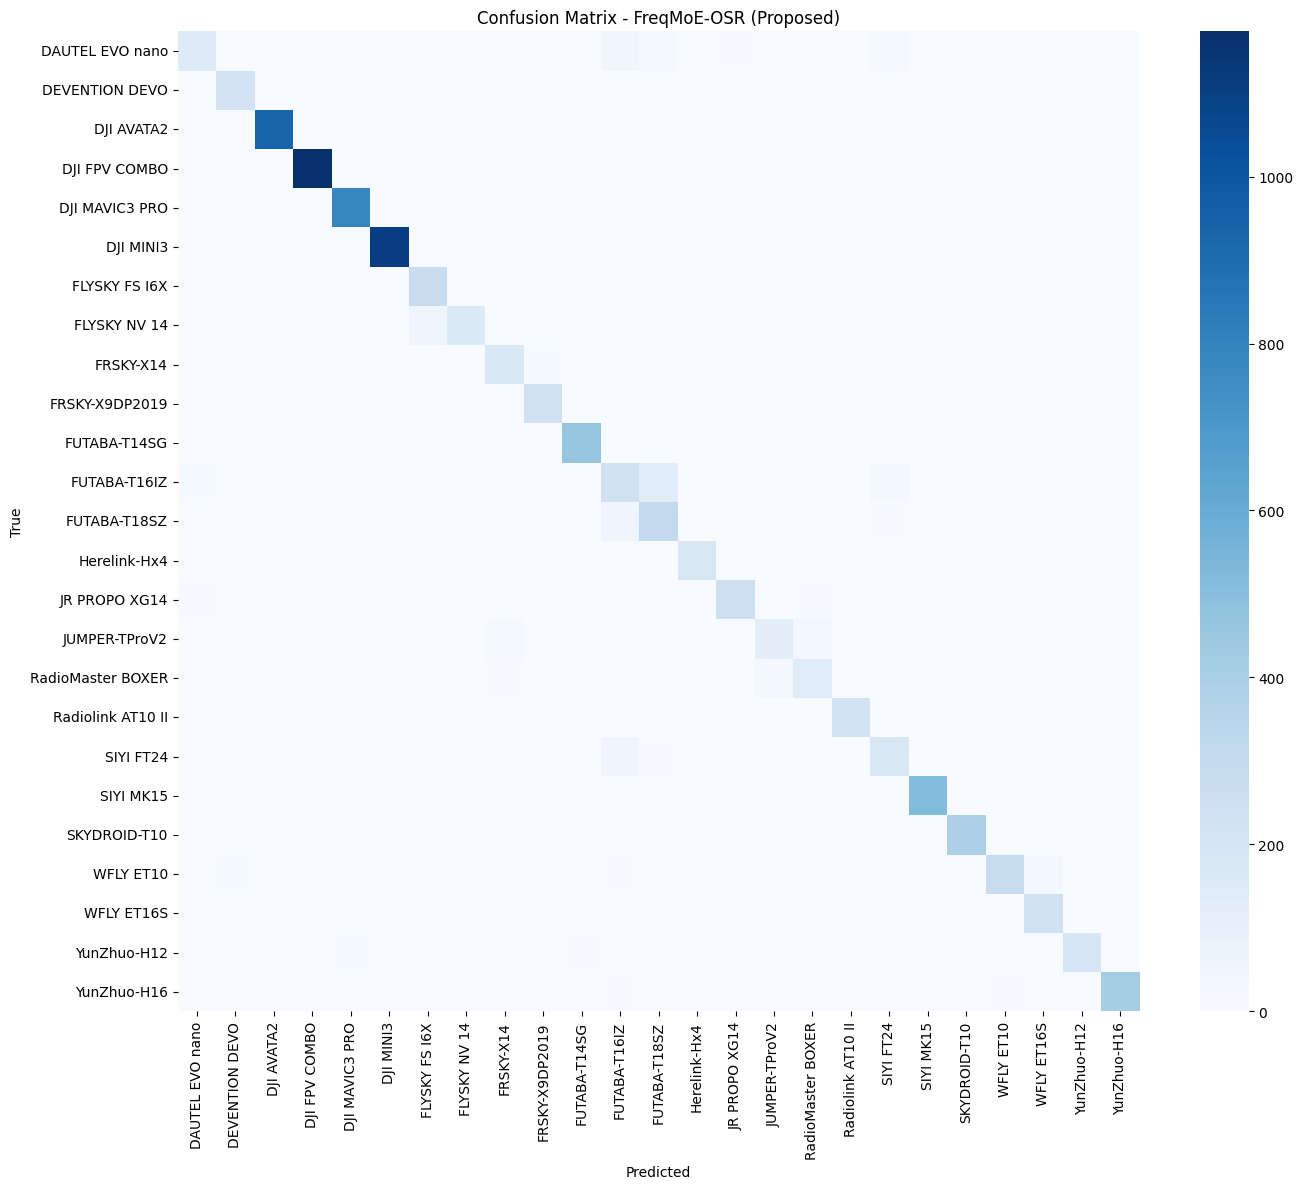

Saved results for FreqMoE-OSR


In [40]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

def compute_routing_entropy(gw):
    eps = 1e-8
    return -torch.sum(gw*torch.log(gw+eps), dim=1)

known_entropies, unknown_entropies = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        _, gw = model(images.to(device))
        known_entropies.extend(compute_routing_entropy(gw).cpu().numpy())
    for images, labels in unknown_img_loader:
        _, gw = model(images.to(device))
        unknown_entropies.extend(compute_routing_entropy(gw).cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_entropies)), np.zeros(len(unknown_entropies))])
y_scores = np.concatenate([-np.array(known_entropies), -np.array(unknown_entropies)])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FreqMoE-OSR (Proposed)'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

In [41]:
model.load_state_dict(best_model_state)
model.eval()

known_entropies_check, unknown_entropies_check = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        _, gw = model(images.to(device))
        known_entropies_check.extend(compute_routing_entropy(gw).cpu().numpy())
    for images, labels in unknown_img_loader:
        _, gw = model(images.to(device))
        unknown_entropies_check.extend(compute_routing_entropy(gw).cpu().numpy())

print(f"Known entropy - mean: {np.mean(known_entropies_check):.4f}, std: {np.std(known_entropies_check):.4f}")
print(f"Unknown entropy - mean: {np.mean(unknown_entropies_check):.4f}, std: {np.std(unknown_entropies_check):.4f}")

Known entropy - mean: 1.1260, std: 0.1591
Unknown entropy - mean: 1.1483, std: 0.1120


In [42]:
model.load_state_dict(best_model_state)
model.eval()

# Use classifier's softmax confidence instead of routing entropy for open-set detection
known_conf_scores, unknown_conf_scores = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        known_conf_scores.extend(probs.max(dim=1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        unknown_conf_scores.extend(probs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_conf_scores)), np.zeros(len(unknown_conf_scores))])
y_scores_new = np.concatenate([known_conf_scores, unknown_conf_scores])

auroc_new = roc_auc_score(y_true_binary, y_scores_new)
print(f"New AUROC (softmax confidence based): {auroc_new:.4f}")
print(f"Known confidence - mean: {np.mean(known_conf_scores):.4f}")
print(f"Unknown confidence - mean: {np.mean(unknown_conf_scores):.4f}")

New AUROC (softmax confidence based): 0.8216
Known confidence - mean: 0.9116
Unknown confidence - mean: 0.7229


In [43]:
# Update the saved FreqMoE-OSR result with the corrected AUROC
save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy,
    'macro_precision': macro_precision,
    'macro_recall': macro_recall,
    'macro_f1': macro_f1,
    'weighted_precision': weighted_precision,
    'weighted_recall': weighted_recall,
    'weighted_f1': weighted_f1,
    'auroc': auroc_new,  # corrected AUROC
    'confusion_matrix': cm
})

Saved results for FreqMoE-OSR


# 5.1 Upgraded FreqMoE-OSR

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class FrequencyExpertPretrained(nn.Module):
    """Frequency-band expert using pretrained ResNet-18 features (shared backbone, separate heads)"""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.proj(feat)


class GatingNetworkV2(nn.Module):
    """Slightly deeper gating network for better expert weighting"""
    def __init__(self, in_channels=3, num_experts=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, num_experts)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class FreqMoE_OSR_V2(nn.Module):
    """
    Upgraded FreqMoE-OSR: pretrained ResNet-18 experts per frequency band + improved gating
    """
    def __init__(self, num_classes, num_experts=4, embed_dim=128, img_size=224):
        super().__init__()
        self.num_experts = num_experts
        self.img_size = img_size
        self.band_height = img_size // num_experts

        self.experts = nn.ModuleList([
            FrequencyExpertPretrained(out_dim=embed_dim) for _ in range(num_experts)
        ])
        self.gate = GatingNetworkV2(in_channels=3, num_experts=num_experts)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        expert_outputs = []
        for i in range(self.num_experts):
            start = i * self.band_height
            end = start + self.band_height if i < self.num_experts - 1 else self.img_size
            strip = x[:, :, start:end, :]
            strip = F.interpolate(strip, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
            expert_outputs.append(self.experts[i](strip))

        expert_outputs = torch.stack(expert_outputs, dim=1)  # [batch, num_experts, embed_dim]
        gate_weights = F.softmax(self.gate(x), dim=1)  # [batch, num_experts]
        fused = torch.sum(expert_outputs * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)
        return logits, gate_weights

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EXPERTS = 4
IMG_SIZE = 224

model = FreqMoE_OSR_V2(num_classes=len(known_classes), num_experts=NUM_EXPERTS, embed_dim=128, img_size=IMG_SIZE).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # lower LR since experts are pretrained now
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 45,424,189


In [59]:
def train_epoch_moe(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, gw = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate_moe(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, gw = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

NUM_EPOCHS = 15
best_valid_acc = 0
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch_moe(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_moe(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

Epoch 1/15 | Train Loss: 1.8650, Train Acc: 0.5356 | Valid Loss: 0.6577, Valid Acc: 0.8132
Epoch 2/15 | Train Loss: 0.3940, Train Acc: 0.9032 | Valid Loss: 0.0824, Valid Acc: 0.9781
Epoch 3/15 | Train Loss: 0.1386, Train Acc: 0.9651 | Valid Loss: 0.0789, Valid Acc: 0.9816
Epoch 4/15 | Train Loss: 0.0694, Train Acc: 0.9842 | Valid Loss: 0.0449, Valid Acc: 0.9885
Epoch 5/15 | Train Loss: 0.0491, Train Acc: 0.9887 | Valid Loss: 0.0376, Valid Acc: 0.9899
Epoch 6/15 | Train Loss: 0.0335, Train Acc: 0.9918 | Valid Loss: 0.0501, Valid Acc: 0.9836
Epoch 7/15 | Train Loss: 0.0392, Train Acc: 0.9903 | Valid Loss: 0.0679, Valid Acc: 0.9799
Epoch 8/15 | Train Loss: 0.0219, Train Acc: 0.9943 | Valid Loss: 0.0320, Valid Acc: 0.9895
Epoch 9/15 | Train Loss: 0.0246, Train Acc: 0.9941 | Valid Loss: 0.0356, Valid Acc: 0.9917
Epoch 10/15 | Train Loss: 0.0157, Train Acc: 0.9972 | Valid Loss: 0.0176, Valid Acc: 0.9959
Epoch 11/15 | Train Loss: 0.0143, Train Acc: 0.9967 | Valid Loss: 0.0204, Valid Acc: 0.99

Accuracy: 0.9958, Macro F1: 0.9943, Weighted F1: 0.9958, AUROC: 0.9817


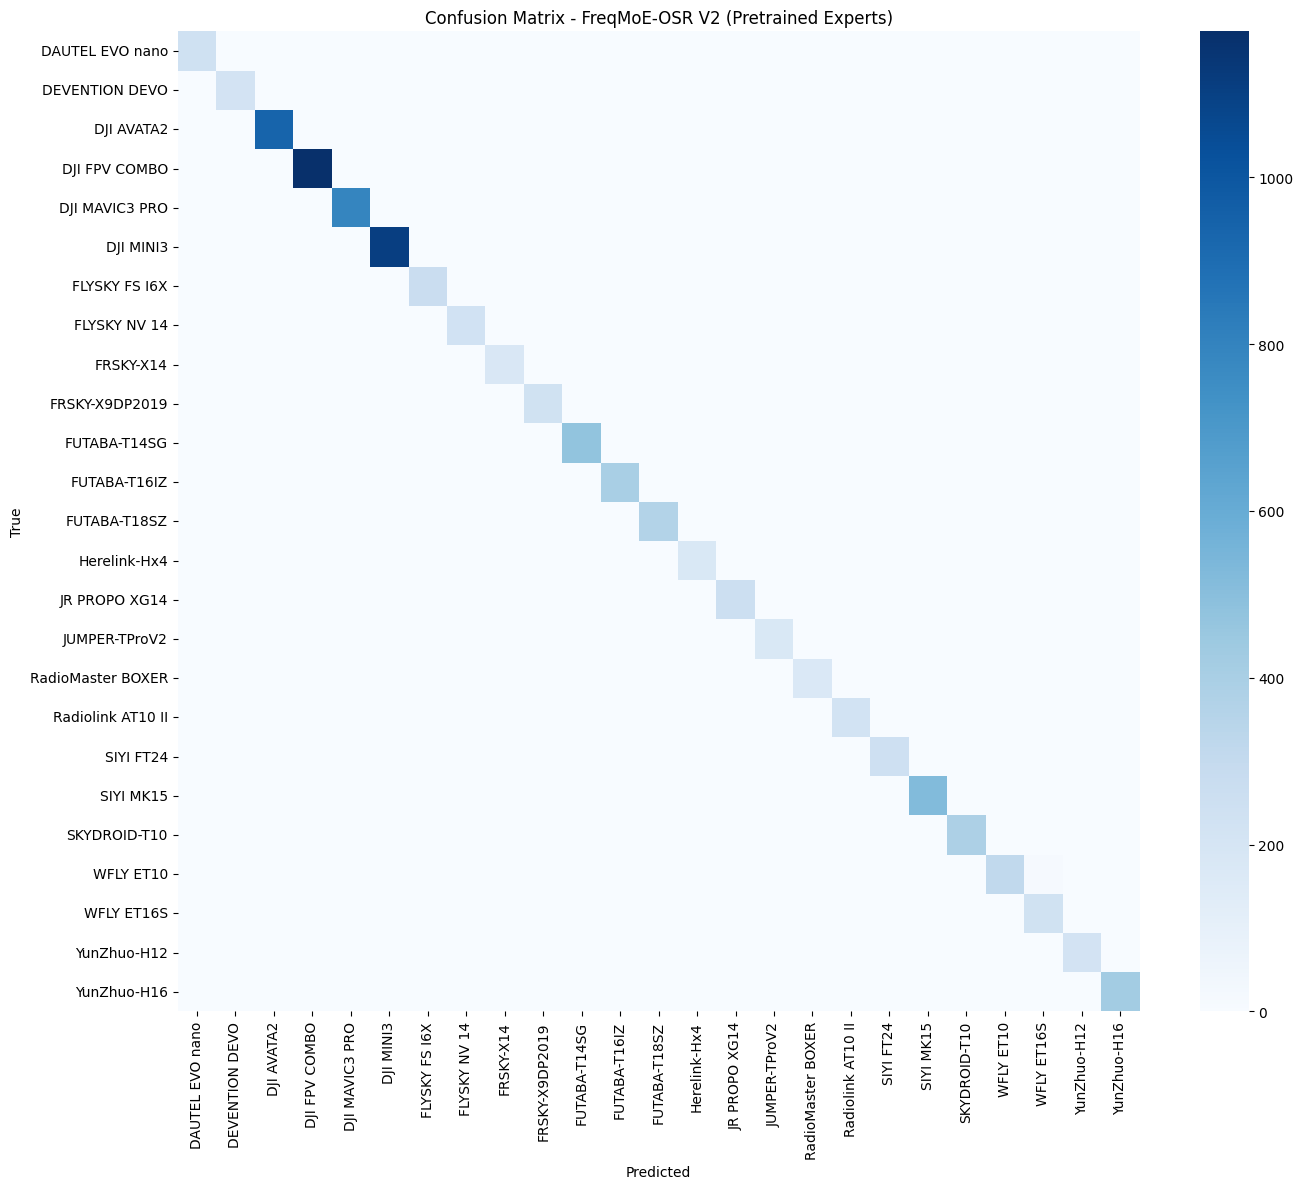

Saved results for FreqMoE-OSR


In [60]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

# Softmax confidence based AUROC (proven to work better than routing entropy)
known_conf, unknown_conf = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        known_conf.extend(probs.max(dim=1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        unknown_conf.extend(probs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_conf)), np.zeros(len(unknown_conf))])
y_scores = np.concatenate([known_conf, unknown_conf])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FreqMoE-OSR V2 (Pretrained Experts)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 6. Final Comparison Table + Chart


In [61]:
import os
print(os.listdir("/kaggle/working/results"))

['FreqMoE_OSR_metrics.csv', 'Swin_Transformer_confusion_matrix.csv', 'DenseNet_121_metrics.txt', 'RNN_metrics.csv', 'FreqMoE_OSR_metrics.json', 'Swin_Transformer_metrics.csv', 'DenseNet_121_metrics.csv', 'Swin_Transformer_metrics.txt', 'Swin_Transformer_metrics.json', 'RNN_metrics.json', 'DenseNet_121_metrics.json', 'RNN_metrics.txt', 'RNN_confusion_matrix.csv', 'FreqMoE_OSR_metrics.txt', 'GNN_metrics.json', 'comparison_table.csv', 'GNN_metrics.csv', 'GNN_confusion_matrix.csv', 'DenseNet_121_confusion_matrix.csv', 'FreqMoE_OSR_confusion_matrix.csv', 'GNN_metrics.txt']


In [62]:
def load_all_results():
    all_results = {}
    for fname in os.listdir(RESULTS_DIR):
        if fname.endswith('.json'):
            with open(os.path.join(RESULTS_DIR, fname), 'r') as f:
                data = json.load(f)
            if 'confusion_matrix' in data: data['confusion_matrix'] = np.array(data['confusion_matrix'])
            all_results[fname.replace('.json','').replace('_',' ')] = data
    return all_results

import pandas as pd
all_results = load_all_results()
rows = [{'Model': m, 'Accuracy': f"{d.get('accuracy',0):.4f}", 'Macro Precision': f"{d.get('macro_precision',0):.4f}",
         'Macro Recall': f"{d.get('macro_recall',0):.4f}", 'Macro F1': f"{d.get('macro_f1',0):.4f}",
         'Weighted F1': f"{d.get('weighted_f1',0):.4f}", 'Open-Set AUROC': f"{d.get('auroc',0):.4f}"} for m, d in all_results.items()]
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)

                   Model Accuracy Macro Precision Macro Recall Macro F1 Weighted F1 Open-Set AUROC
     FreqMoE OSR metrics   0.9958          0.9937       0.9950   0.9943      0.9958         0.9817
Swin Transformer metrics   0.9951          0.9934       0.9943   0.9938      0.9951         0.9131
             RNN metrics   0.4996          0.2809       0.3360   0.2773      0.4352         0.6721
    DenseNet 121 metrics   0.9321          0.9099       0.9012   0.9025      0.9316         0.4763
             GNN metrics   0.7050          0.7127       0.6586   0.6057      0.6754         0.7326


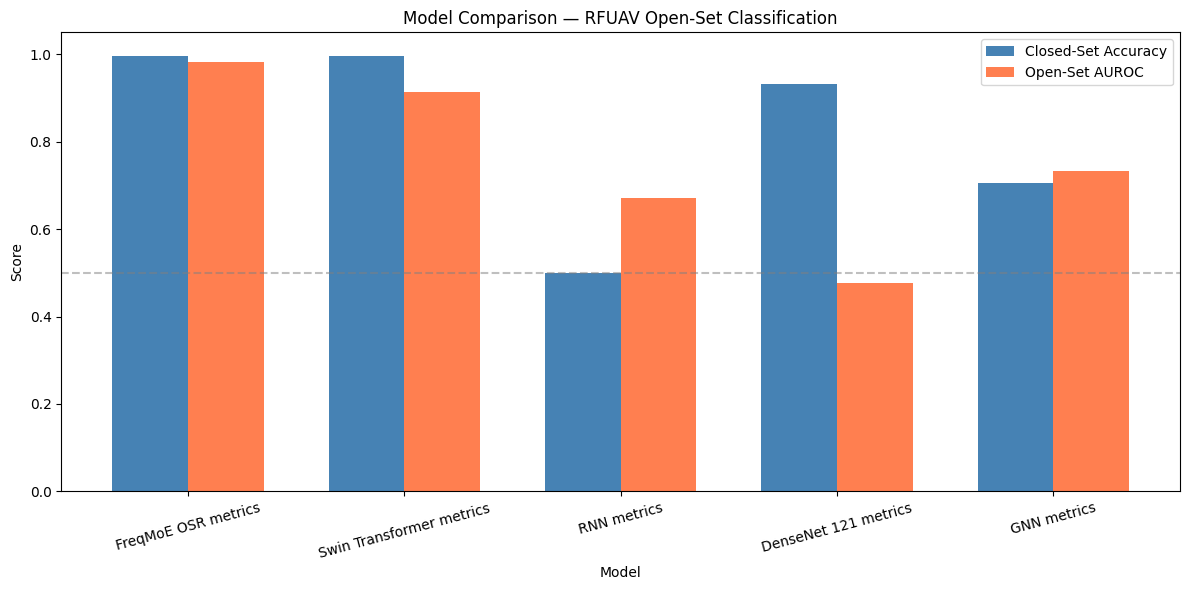

Final comparison chart saved!


In [63]:
import matplotlib.pyplot as plt
import numpy as np

all_results = load_all_results()
models = list(all_results.keys())
accuracy_vals = [all_results[m].get('accuracy', 0) for m in models]
auroc_vals = [all_results[m].get('auroc', 0) for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, accuracy_vals, width, label='Closed-Set Accuracy', color='steelblue')
ax.bar(x + width/2, auroc_vals, width, label='Open-Set AUROC', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — RFUAV Open-Set Classification')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance (AUROC)')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/final_comparison_chart.png", dpi=150)
plt.show()

print("Final comparison chart saved!")

In [64]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

all_results = load_all_results()

rows = []

for model_name, d in all_results.items():
    rows.append({
        "Model": model_name,
        "Accuracy": d.get("accuracy", 0),
        "Precision (Macro)": d.get("macro_precision", 0),
        "Recall (Macro)": d.get("macro_recall", 0),
        "F1-Score (Macro)": d.get("macro_f1", 0),
        "Precision (Weighted)": d.get("weighted_precision", 0),
        "Recall (Weighted)": d.get("weighted_recall", 0),
        "F1-Score (Weighted)": d.get("weighted_f1", 0),
        "Open-Set AUROC": d.get("auroc", 0)
    })

comparison_df = pd.DataFrame(rows)

metric_columns = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
    "Precision (Weighted)",
    "Recall (Weighted)",
    "F1-Score (Weighted)",
    "Open-Set AUROC"
]

comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

print("\n" + "=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)

display(comparison_df)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

comparison_csv = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.csv"
)

comparison_df.to_csv(
    comparison_csv,
    index=False
)

# ------------------------------------------------------------
# SAVE EXCEL
# ------------------------------------------------------------

comparison_excel = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.xlsx"
)

comparison_df.to_excel(
    comparison_excel,
    index=False
)

# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

comparison_json = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.json"
)

comparison_df.to_json(
    comparison_json,
    orient="records",
    indent=4
)

print("\nSaved:")
print(comparison_csv)
print(comparison_excel)
print(comparison_json)



FINAL MODEL COMPARISON


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Precision (Weighted),Recall (Weighted),F1-Score (Weighted),Open-Set AUROC
0,FreqMoE OSR metrics,0.9958,0.9937,0.9950,0.9943,0.9959,0.9958,0.9958,0.9817
1,Swin Transformer metrics,0.9951,0.9934,0.9943,0.9938,0.9953,0.9951,0.9951,0.9131
2,RNN metrics,0.4996,0.2809,0.3360,0.2773,0.4315,0.4996,0.4352,0.6721
3,DenseNet 121 metrics,0.9321,0.9099,0.9012,0.9025,0.9351,0.9321,0.9316,0.4763
4,GNN metrics,0.7050,0.7127,0.6586,0.6057,0.7665,0.7050,0.6754,0.7326



Saved:
/kaggle/working/results/FINAL_MODEL_COMPARISON.csv
/kaggle/working/results/FINAL_MODEL_COMPARISON.xlsx
/kaggle/working/results/FINAL_MODEL_COMPARISON.json


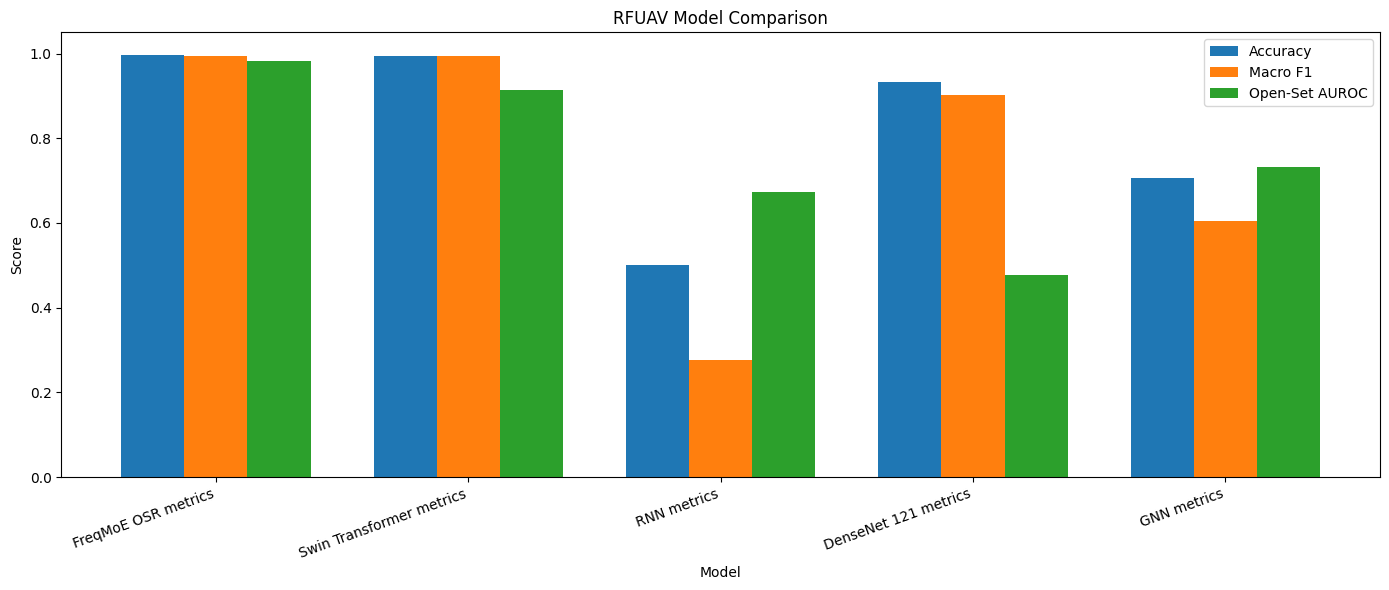

Chart saved: /kaggle/working/results/final_model_comparison_chart.png


In [65]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

models_list = comparison_df["Model"].tolist()

accuracy_vals = comparison_df["Accuracy"].values
macro_f1_vals = comparison_df["F1-Score (Macro)"].values
auroc_vals = comparison_df["Open-Set AUROC"].values

x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width,
    accuracy_vals,
    width,
    label="Accuracy"
)

ax.bar(
    x,
    macro_f1_vals,
    width,
    label="Macro F1"
)

ax.bar(
    x + width,
    auroc_vals,
    width,
    label="Open-Set AUROC"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("RFUAV Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()

chart_path = os.path.join(
    RESULTS_DIR,
    "final_model_comparison_chart.png"
)

plt.savefig(
    chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved: {chart_path}")


In [69]:
import pandas as pd

comparison_df = pd.read_csv("/kaggle/working/results/FINAL_MODEL_COMPARISON.csv")
print(comparison_df.to_string(index=False))

# Rename column for consistency if needed
comparison_df.columns = [c.strip() for c in comparison_df.columns]

                   Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)  Open-Set AUROC
     FreqMoE OSR metrics    0.9958             0.9937          0.9950            0.9943                0.9959             0.9958               0.9958          0.9817
Swin Transformer metrics    0.9951             0.9934          0.9943            0.9938                0.9953             0.9951               0.9951          0.9131
             RNN metrics    0.4996             0.2809          0.3360            0.2773                0.4315             0.4996               0.4352          0.6721
    DenseNet 121 metrics    0.9321             0.9099          0.9012            0.9025                0.9351             0.9321               0.9316          0.4763
             GNN metrics    0.7050             0.7127          0.6586            0.6057                0.7665             0.7050               0.6754          0.7326


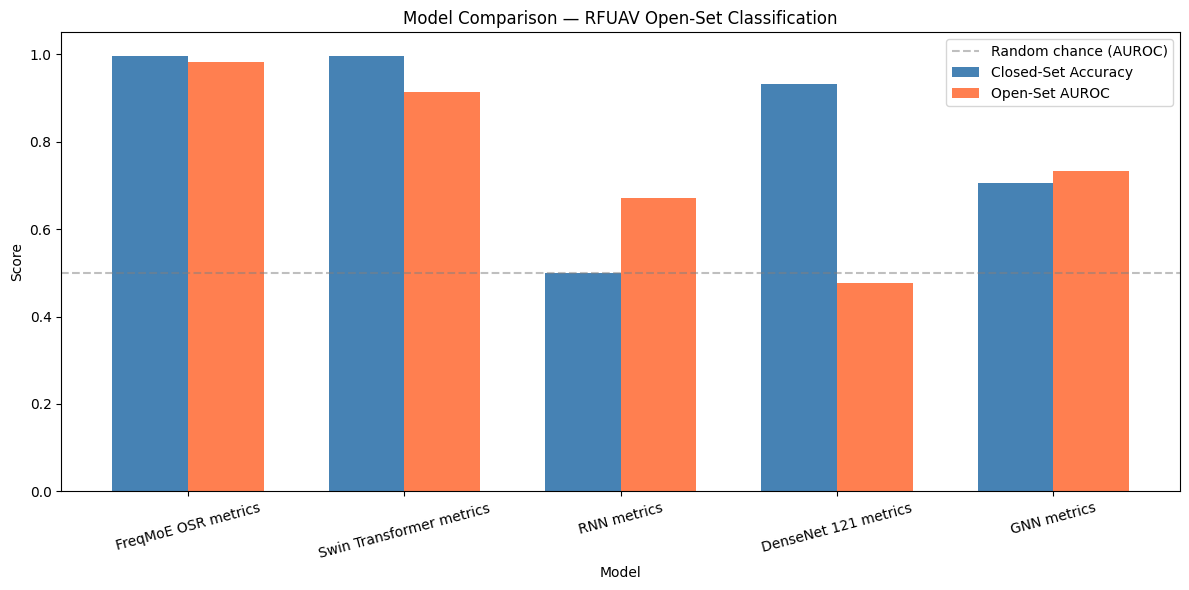

Final comparison chart saved!


In [70]:
import matplotlib.pyplot as plt
import numpy as np

models_list = comparison_df['Model'].tolist()
accuracy_vals = comparison_df['Accuracy'].astype(float).tolist()
auroc_vals = comparison_df['Open-Set AUROC'].astype(float).tolist()

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, accuracy_vals, width, label='Closed-Set Accuracy', color='steelblue')
ax.bar(x + width/2, auroc_vals, width, label='Open-Set AUROC', color='coral')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance (AUROC)')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — RFUAV Open-Set Classification')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("/kaggle/working/results/final_comparison_chart.png", dpi=150)
plt.show()
print("Final comparison chart saved!")

# 7. Restricted-Airspace Simulator

Uses the trained FreqMoE-OSR model on real spectrograms to demonstrate:

```
RF Spectrogram → FreqMoE-OSR → Known/Unknown →
   (Known) → Identify UAV type → SAFE
   (Unknown) → Risk Analysis → Alert → Counter-UAV Response [SIMULATED] → Threat Neutralized [SIMULATED]
```
```

In [71]:
print("model" in dir())
print("eval_transform" in dir())

True
True


In [72]:
import random
from PIL import Image
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

model.eval()

# Determine rejection threshold using known-class confidence distribution
known_conf_sim = []
with torch.no_grad():
    for x, y in valid_img_loader:
        out = model(x.to(device))
        logits = out[0] if isinstance(out, tuple) else out  # handles both (logits,) and (logits, gate) returns
        probs = F.softmax(logits, dim=1)
        known_conf_sim.extend(probs.max(dim=1)[0].cpu().numpy())

REJECTION_THRESHOLD = float(np.percentile(known_conf_sim, 5))
print(f"Rejection threshold (5th percentile of known confidence): {REJECTION_THRESHOLD:.4f}")

Rejection threshold (5th percentile of known confidence): 0.9990


In [73]:
def classify_event(img_path):
    image = Image.open(img_path).convert('RGB')
    image = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(image)
        logits = out[0] if isinstance(out, tuple) else out
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    conf = conf.item()
    pred_class = idx_to_class[pred_idx.item()]
    is_known = conf >= REJECTION_THRESHOLD
    return is_known, pred_class, conf

NUM_EVENTS = 12
sim_events = []

known_sample_paths = random.sample(known_valid_paths, NUM_EVENTS // 2)
unknown_sample_paths = random.sample(unknown_test_paths, NUM_EVENTS - NUM_EVENTS // 2)

known_lookup = dict(zip(known_valid_paths, known_valid_labels))
unknown_lookup = dict(zip(unknown_test_paths, unknown_test_labels))

for p in known_sample_paths:
    sim_events.append({'path': p, 'true_label': known_lookup[p], 'true_authorized': True})
for p in unknown_sample_paths:
    sim_events.append({'path': p, 'true_label': unknown_lookup[p], 'true_authorized': False})

random.shuffle(sim_events)

ZONE_CENTER = (0, 0)
ZONE_RADIUS = 10
for event in sim_events:
    angle = random.uniform(0, 2 * np.pi)
    dist = random.uniform(2, ZONE_RADIUS)
    event['x'] = ZONE_CENTER[0] + dist * np.cos(angle)
    event['y'] = ZONE_CENTER[1] + dist * np.sin(angle)

for event in sim_events:
    is_known, pred_class, conf = classify_event(event['path'])
    event['predicted_known'] = is_known
    event['predicted_class'] = pred_class if is_known else 'UNKNOWN'
    event['confidence'] = conf
    dist_from_center = np.sqrt(event['x']**2 + event['y']**2)
    event['risk_level'] = 'HIGH' if dist_from_center < 4 else ('MEDIUM' if dist_from_center < 7 else 'LOW')

print("Inference complete on all simulated events!")
for e in sim_events:
    status = f"Known ({e['predicted_class']})" if e['predicted_known'] else "UNKNOWN/UNAUTHORIZED"
    print(f"  Pos=({e['x']:.1f},{e['y']:.1f}) | True={e['true_label']} | Predicted={status} | Conf={e['confidence']:.3f}")

Inference complete on all simulated events!
  Pos=(-7.2,-4.5) | True=FLYSKY FS I6X | Predicted=Known (FLYSKY FS I6X) | Conf=1.000
  Pos=(8.4,0.3) | True=DJI FPV COMBO | Predicted=Known (DJI FPV COMBO) | Conf=1.000
  Pos=(-1.5,-4.5) | True=WFLY WFT09SII | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.332
  Pos=(5.4,8.0) | True=SIYI MK32 | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.999
  Pos=(-1.4,2.3) | True=SIYI MK32 | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.633
  Pos=(7.2,5.0) | True=FLYSKY EL 18 | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.954
  Pos=(-6.7,-5.1) | True=DJI MINI3 | Predicted=Known (DJI MINI3) | Conf=1.000
  Pos=(-0.8,-6.2) | True=DJI FPV COMBO | Predicted=Known (DJI FPV COMBO) | Conf=1.000
  Pos=(5.0,-0.8) | True=RadioMaster TX16S | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.480
  Pos=(-8.2,-2.8) | True=FLYSKY EL 18 | Predicted=UNKNOWN/UNAUTHORIZED | Conf=0.684
  Pos=(-6.5,-6.0) | True=DJI MINI3 | Predicted=Known (DJI MINI3) | Conf=1.000
  Pos=(-6.8,-3.6) | True=DEVENTION DEVO | Pred

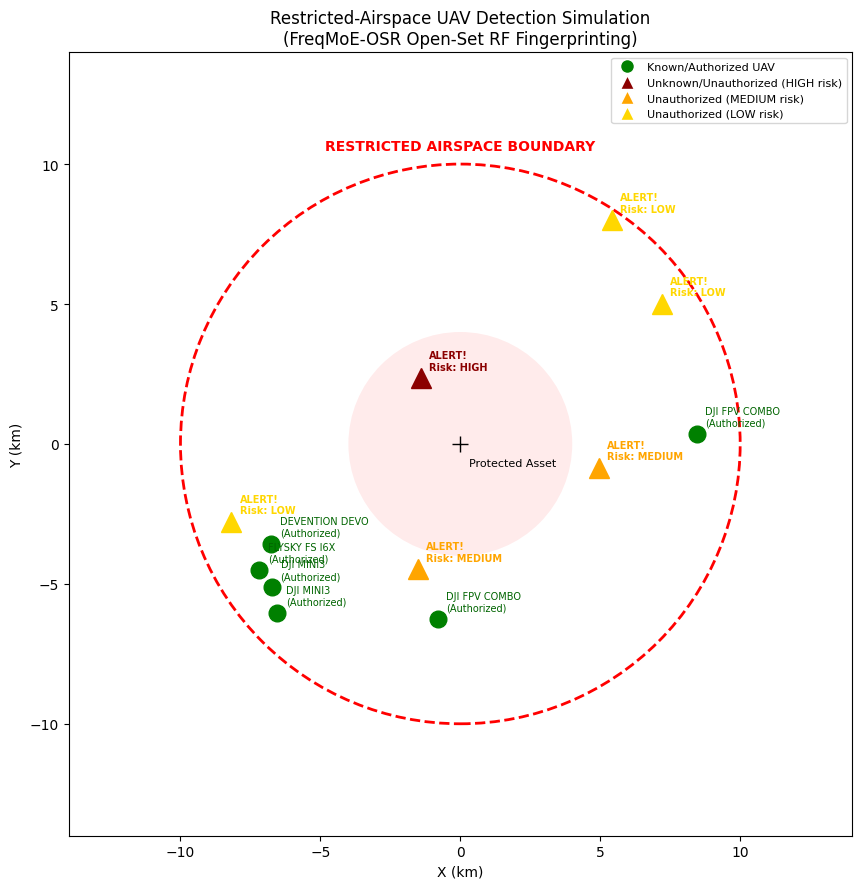

In [74]:
fig, ax = plt.subplots(figsize=(9, 9))

zone = Circle(ZONE_CENTER, ZONE_RADIUS, fill=False, edgecolor='red', linewidth=2, linestyle='--')
ax.add_patch(zone)
inner_zone = Circle(ZONE_CENTER, 4, fill=True, facecolor='red', alpha=0.08)
ax.add_patch(inner_zone)

ax.text(0, ZONE_RADIUS + 0.5, "RESTRICTED AIRSPACE BOUNDARY", ha='center', fontsize=10, color='red', weight='bold')
ax.plot(0, 0, 'k+', markersize=12)
ax.text(0.3, -0.8, "Protected Asset", fontsize=8)

for e in sim_events:
    if e['predicted_known']:
        ax.plot(e['x'], e['y'], 'o', color='green', markersize=12)
        ax.text(e['x']+0.3, e['y']+0.3, f"{e['predicted_class']}\n(Authorized)", fontsize=7, color='darkgreen')
    else:
        color = {'HIGH': 'darkred', 'MEDIUM': 'orange', 'LOW': 'gold'}[e['risk_level']]
        ax.plot(e['x'], e['y'], '^', color=color, markersize=14)
        ax.text(e['x']+0.3, e['y']+0.3, f"ALERT!\nRisk: {e['risk_level']}", fontsize=7, color=color, weight='bold')

ax.set_xlim(-14, 14)
ax.set_ylim(-14, 14)
ax.set_aspect('equal')
ax.set_title('Restricted-Airspace UAV Detection Simulation\n(FreqMoE-OSR Open-Set RF Fingerprinting)', fontsize=12)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Known/Authorized UAV'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='darkred', markersize=10, label='Unknown/Unauthorized (HIGH risk)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='orange', markersize=10, label='Unauthorized (MEDIUM risk)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gold', markersize=10, label='Unauthorized (LOW risk)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
-
plt.tight_layout()
plt.savefig("/kaggle/working/results/airspace_simulation_map.png", dpi=150)
plt.show()

In [75]:
import json

sim_report = []
for e in sim_events:
    sim_report.append({
        'position': [round(e['x'], 2), round(e['y'], 2)],
        'true_label': e['true_label'],
        'true_authorized': e['true_authorized'],
        'predicted_known': e['predicted_known'],
        'predicted_class': e['predicted_class'],
        'confidence': round(e['confidence'], 4),
        'risk_level': e.get('risk_level', 'N/A')
    })

with open("/kaggle/working/results/simulation_report.json", 'w') as f:
    json.dump(sim_report, f, indent=4)

print("Simulation report saved!")

Simulation report saved!


In [76]:
# ============================================================
# SAVE SIMULATOR RESULTS
# ============================================================

sim_report = []

for e in sim_events:
    sim_report.append({
        "x": round(float(e["x"]), 2),
        "y": round(float(e["y"]), 2),
        "true_label": e["true_label"],
        "true_authorized": e["true_authorized"],
        "predicted_known": e["predicted_known"],
        "predicted_class": e["predicted_class"],
        "confidence": round(float(e["confidence"]), 4),
        "risk_level": e.get("risk_level", "N/A")
    })

sim_df = pd.DataFrame(sim_report)

# JSON
simulation_json = os.path.join(
    RESULTS_DIR,
    "simulation_report.json"
)

with open(simulation_json, "w") as f:
    json.dump(sim_report, f, indent=4)

# CSV
simulation_csv = os.path.join(
    RESULTS_DIR,
    "simulation_report.csv"
)

sim_df.to_csv(
    simulation_csv,
    index=False
)

print("Simulation results saved:")
print(simulation_json)
print(simulation_csv)

print("\n" + "=" * 70)
print("ALL EXPERIMENT RESULTS SAVED")
print("=" * 70)
print(f"Results folder     : {RESULTS_DIR}")
print(f"Checkpoints folder : {CHECKPOINTS_DIR}")
print("\nPer-model metrics: JSON + CSV + TXT")
print("Per-model confusion matrices: CSV")
print("Per-model trained weights: .pt")
print("Final comparison: CSV + Excel + JSON")
print("Simulator report: CSV + JSON")


Simulation results saved:
/kaggle/working/results/simulation_report.json
/kaggle/working/results/simulation_report.csv

ALL EXPERIMENT RESULTS SAVED
Results folder     : /kaggle/working/results
Checkpoints folder : /kaggle/working/checkpoints

Per-model metrics: JSON + CSV + TXT
Per-model confusion matrices: CSV
Per-model trained weights: .pt
Final comparison: CSV + Excel + JSON
Simulator report: CSV + JSON


In [6]:
import json
from kaggle_secrets import UserSecretsClient
from google.oauth2 import service_account
from googleapiclient.discovery import build

user_secrets = UserSecretsClient()
creds_json = user_secrets.get_secret("GDRIVE_CREDS")
creds_dict = json.loads(creds_json)

credentials = service_account.Credentials.from_service_account_info(
    creds_dict, scopes=["https://www.googleapis.com/auth/drive.readonly"]
)
drive_service = build("drive", "v3", credentials=credentials)
print("Authenticated successfully!")

Authenticated successfully!


In [9]:
dronerf_folder_id = "1LXNAEVAmL600bPGG30KgU4l2_KkzVQx0"

results = drive_service.files().list(
    q=f"'{dronerf_folder_id}' in parents",
    fields="files(id, name, mimeType)",
    pageSize=100
).execute()

files = results.get('files', [])
print(f"Found {len(files)} items")
for f in files[:20]:
    print(f['name'], '-', f['mimeType'])

Found 8 items
dataset_split - application/vnd.google-apps.folder
spectrograms - application/vnd.google-apps.folder
spectrogram_dataset - application/vnd.google-apps.folder
results - application/vnd.google-apps.folder
datasets - application/vnd.google-apps.folder
notebooks - application/vnd.google-apps.folder
outputs - application/vnd.google-apps.folder
models - application/vnd.google-apps.folder


In [10]:
def list_folder_contents(folder_id, folder_name=""):
    results = drive_service.files().list(
        q=f"'{folder_id}' in parents",
        fields="files(id, name, mimeType)",
        pageSize=100
    ).execute()
    files = results.get('files', [])
    print(f"\n--- Contents of '{folder_name}' ---")
    for f in files:
        print(f['name'], '-', f['mimeType'])
    return files

# First, get the IDs of each top-level folder
all_items = {f['name']: f['id'] for f in files}
print(all_items)

{'dataset_split': '1aPuxyppm1XfMSnGkJp00eaYqFsDn1Qvy', 'spectrograms': '1Q7wnp70RiqEoHt_ifJUHIPfY00DItbyS', 'spectrogram_dataset': '1o295S-gBozcBFieq8VLHWqETnwlaFfPV', 'results': '1OAmvFs2OrU8RHod6sT9OdIj24Iqes-eZ', 'datasets': '1RE6_FtAvcLkYSAIgRU48qzdCL8hvXcmr', 'notebooks': '18s81ib8EDqxuHFLUCYVFFcG6S-acrrnL', 'outputs': '1svZd4VNOna4thA95AvnTilkWlqYnKxgb', 'models': '1xPTt5HN7kNBMQzWh-LB-Zqj0Gz_UleQf'}


In [11]:
# Explore 'spectrograms' folder
spectrograms_items = list_folder_contents(all_items['spectrograms'], 'spectrograms')


--- Contents of 'spectrograms' ---
class_20 - application/vnd.google-apps.folder
class_19 - application/vnd.google-apps.folder
class_18 - application/vnd.google-apps.folder
class_17 - application/vnd.google-apps.folder
class_16 - application/vnd.google-apps.folder
class_15 - application/vnd.google-apps.folder
class_14 - application/vnd.google-apps.folder
class_13 - application/vnd.google-apps.folder
class_12 - application/vnd.google-apps.folder
class_11 - application/vnd.google-apps.folder
class_10 - application/vnd.google-apps.folder
class_9 - application/vnd.google-apps.folder
class_8 - application/vnd.google-apps.folder
class_7 - application/vnd.google-apps.folder
class_6 - application/vnd.google-apps.folder
class_5 - application/vnd.google-apps.folder
class_4 - application/vnd.google-apps.folder
class_3 - application/vnd.google-apps.folder
class_2 - application/vnd.google-apps.folder
class_1 - application/vnd.google-apps.folder
class_0 - application/vnd.google-apps.folder


In [12]:
# Explore 'spectrogram_dataset' folder
spectrogram_dataset_items = list_folder_contents(all_items['spectrogram_dataset'], 'spectrogram_dataset')


--- Contents of 'spectrogram_dataset' ---
class_20 - application/vnd.google-apps.folder
class_19 - application/vnd.google-apps.folder
class_18 - application/vnd.google-apps.folder
class_17 - application/vnd.google-apps.folder
class_16 - application/vnd.google-apps.folder
class_15 - application/vnd.google-apps.folder
class_14 - application/vnd.google-apps.folder
class_13 - application/vnd.google-apps.folder
class_12 - application/vnd.google-apps.folder
class_11 - application/vnd.google-apps.folder
class_10 - application/vnd.google-apps.folder
class_9 - application/vnd.google-apps.folder
class_8 - application/vnd.google-apps.folder
class_7 - application/vnd.google-apps.folder
class_6 - application/vnd.google-apps.folder
class_5 - application/vnd.google-apps.folder
class_4 - application/vnd.google-apps.folder
class_3 - application/vnd.google-apps.folder
class_2 - application/vnd.google-apps.folder
class_1 - application/vnd.google-apps.folder
class_0 - application/vnd.google-apps.folder


In [13]:
# Explore 'dataset_split' folder too - might have train/test/val structure
dataset_split_items = list_folder_contents(all_items['dataset_split'], 'dataset_split')


--- Contents of 'dataset_split' ---
val - application/vnd.google-apps.folder
train - application/vnd.google-apps.folder


In [14]:
# class_0 folder-க்குள் என்ன இருக்கு பாருங்க
class_0_items = list_folder_contents(spectrograms_items[-1]['id'], 'spectrograms/class_0')


--- Contents of 'spectrograms/class_0' ---


In [15]:
# dataset_split/train folder-க்குள் class structure இருக்கானு பாருங்க
train_items = list_folder_contents(dataset_split_items[1]['id'], 'dataset_split/train')


--- Contents of 'dataset_split/train' ---
class_20 - application/vnd.google-apps.folder
class_19 - application/vnd.google-apps.folder
class_18 - application/vnd.google-apps.folder
class_17 - application/vnd.google-apps.folder
class_16 - application/vnd.google-apps.folder
class_15 - application/vnd.google-apps.folder
class_14 - application/vnd.google-apps.folder
class_13 - application/vnd.google-apps.folder
class_12 - application/vnd.google-apps.folder
class_11 - application/vnd.google-apps.folder
class_10 - application/vnd.google-apps.folder
class_9 - application/vnd.google-apps.folder
class_8 - application/vnd.google-apps.folder
class_7 - application/vnd.google-apps.folder
class_6 - application/vnd.google-apps.folder
class_5 - application/vnd.google-apps.folder
class_4 - application/vnd.google-apps.folder
class_3 - application/vnd.google-apps.folder
class_2 - application/vnd.google-apps.folder
class_1 - application/vnd.google-apps.folder
class_0 - application/vnd.google-apps.folder


In [16]:
# Also check val
val_items = list_folder_contents(dataset_split_items[0]['id'], 'dataset_split/val')


--- Contents of 'dataset_split/val' ---
class_15 - application/vnd.google-apps.folder
class_14 - application/vnd.google-apps.folder
class_13 - application/vnd.google-apps.folder
class_12 - application/vnd.google-apps.folder
class_11 - application/vnd.google-apps.folder
class_10 - application/vnd.google-apps.folder
class_9 - application/vnd.google-apps.folder
class_8 - application/vnd.google-apps.folder
class_7 - application/vnd.google-apps.folder
class_6 - application/vnd.google-apps.folder
class_5 - application/vnd.google-apps.folder
class_4 - application/vnd.google-apps.folder
class_3 - application/vnd.google-apps.folder
class_2 - application/vnd.google-apps.folder
class_1 - application/vnd.google-apps.folder
class_0 - application/vnd.google-apps.folder
